In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, brier_score_loss, log_loss, roc_curve, precision_recall_curve
)
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.calibration import calibration_curve


AUC:        0.8097
Accuracy:   0.7113
Precision:  0.7516
Recall:     0.6310
F1:         0.6861
Brier:      0.1861
Log loss:   0.6059
Confusion matrix [tn=1583, fp=417, fn=738, tp=1262]
  Specificity (TNR): 0.7915
  FPR:               0.2085


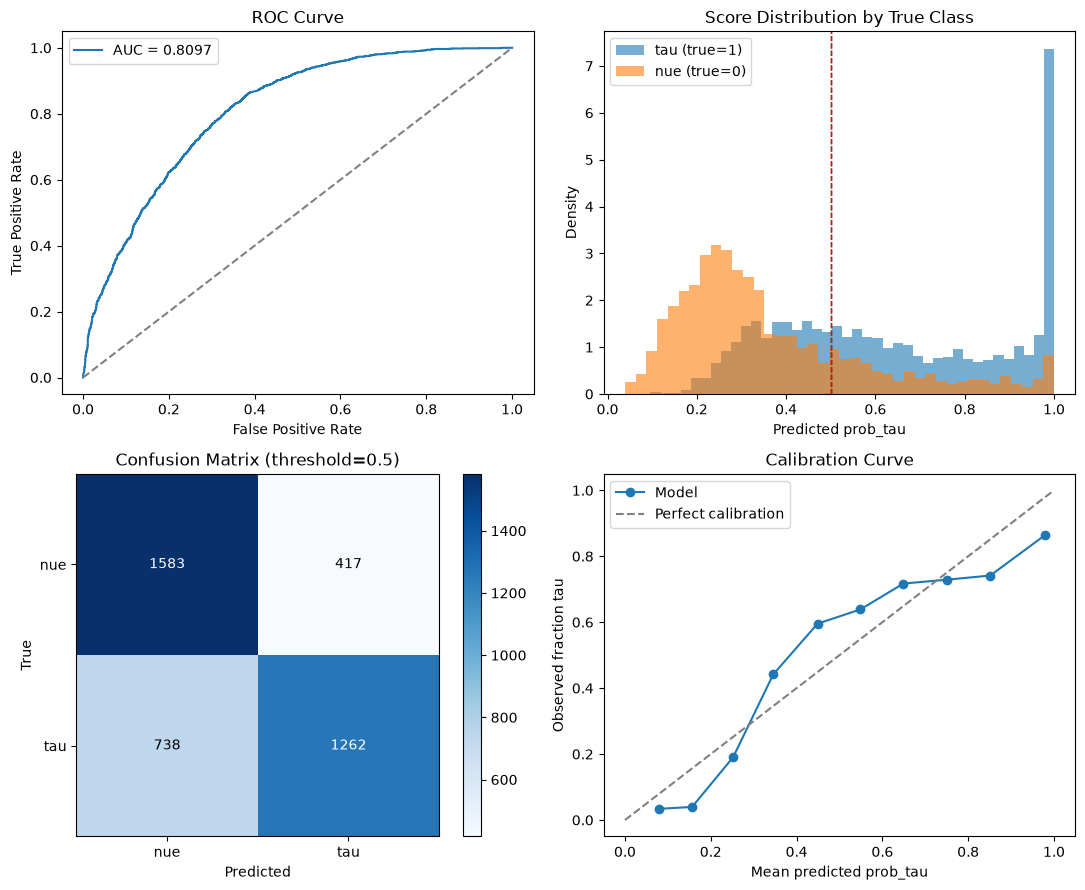

Best threshold: 0.3400
  Tau recovery:  0.8605
  Nue rejection: 0.6160
  Sum:           1.4765


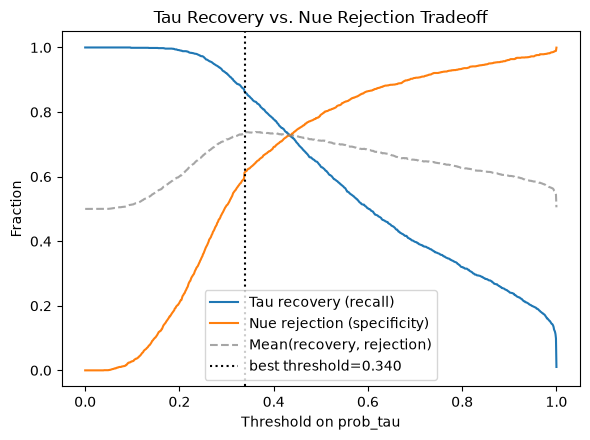

alpha=0.7  ->  best threshold: 0.5960
  Tau recovery:  0.5075
  Nue rejection: 0.8630
 alpha  threshold   recovery  rejection
  0.50     0.3400     0.8605     0.6160
  0.60     0.4290     0.7360     0.7255
  0.70     0.5960     0.5075     0.8630
  0.80     0.9160     0.2290     0.9680
  0.90     0.9970     0.1190     0.9890
  1.00     1.0000     0.0105     0.9995


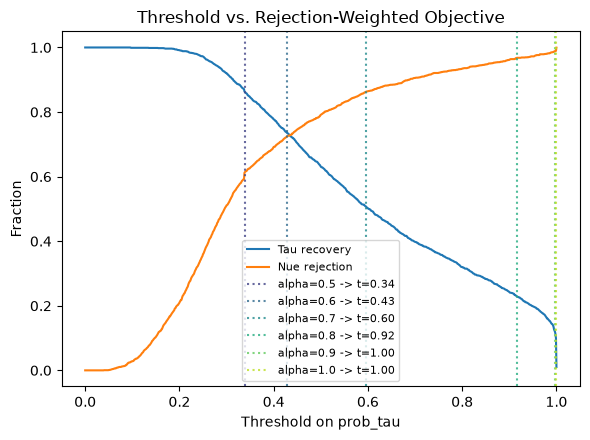

In [3]:
df = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/infer_dom_level_train_GAT_beforeresume/scores.csv")
threshold = 0.5
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")


thresholds = np.linspace(0.0, 1.0, 1001)
recoveries = np.array([tau_recovery(y_true, y_prob, t) for t in thresholds])
rejections = np.array([nue_rejection(y_true, y_prob, t) for t in thresholds])

combined = recoveries + rejections  # maximize this
best_idx = np.argmax(combined)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")
print(f"  Sum:           {combined[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.plot(thresholds, combined / 2, "--", color="gray", alpha=0.7, label="Mean(recovery, rejection)")
ax.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
           label=f"best threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()


alpha = 0.7  # weight on nue rejection; (1-alpha) on tau recovery. alpha=0.5 == unweighted.

weighted_score = alpha * rejections + (1 - alpha) * recoveries
best_idx = np.argmax(weighted_score)
best_threshold = thresholds[best_idx]

print(f"alpha={alpha}  ->  best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")

alphas = np.linspace(0.5, 1.0, 6)
print(f"{'alpha':>6} {'threshold':>10} {'recovery':>10} {'rejection':>10}")
for a in alphas:
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    print(f"{a:6.2f} {thresholds[idx]:10.4f} {recoveries[idx]:10.4f} {rejections[idx]:10.4f}")


fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery")
ax.plot(thresholds, rejections, label="Nue rejection")
for a, color in zip(alphas, plt.cm.viridis(np.linspace(0.2, 0.9, len(alphas)))):
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    ax.axvline(thresholds[idx], color=color, linestyle=":", alpha=0.8,
               label=f"alpha={a} -> t={thresholds[idx]:.2f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Threshold vs. Rejection-Weighted Objective")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

AUC:        0.8084
Accuracy:   0.7185
Precision:  0.7355
Recall:     0.6825
F1:         0.7080
Brier:      0.1825
Log loss:   0.6442
Confusion matrix [tn=1509, fp=491, fn=635, tp=1365]
  Specificity (TNR): 0.7545
  FPR:               0.2455


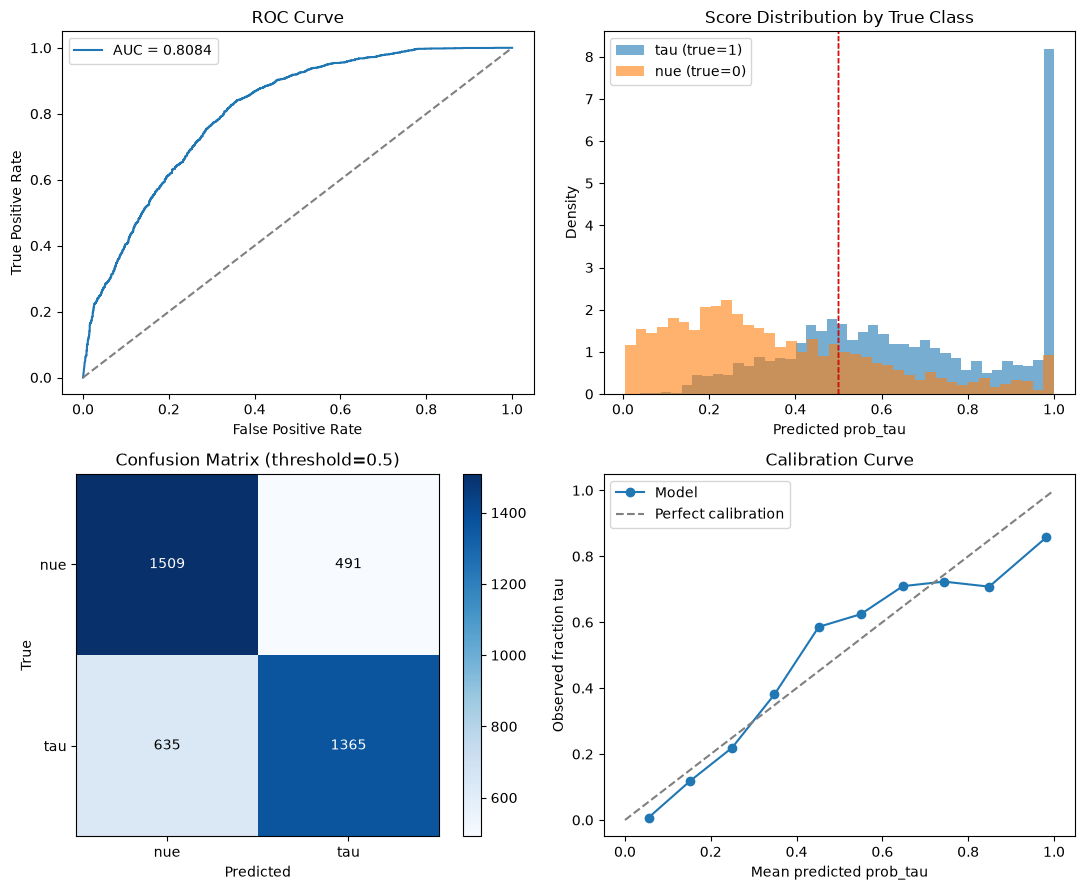

Best threshold: 0.3970
  Tau recovery:  0.8395
  Nue rejection: 0.6425
  Sum:           1.4820


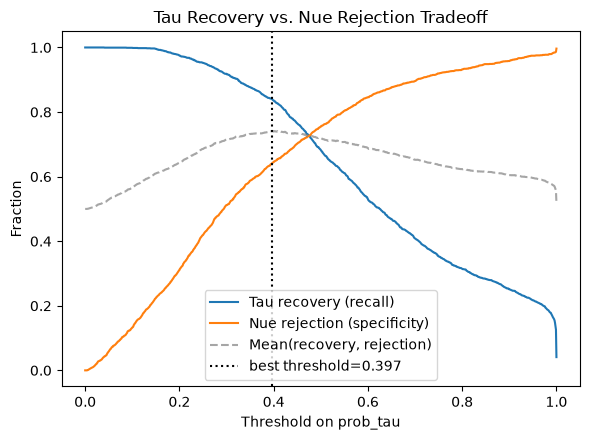

In [4]:
df = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/infer_dom_level_train_GAT_resume/scores.csv")
threshold = 0.5
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")


thresholds = np.linspace(0.0, 1.0, 1001)
recoveries = np.array([tau_recovery(y_true, y_prob, t) for t in thresholds])
rejections = np.array([nue_rejection(y_true, y_prob, t) for t in thresholds])

combined = recoveries + rejections  # maximize this
best_idx = np.argmax(combined)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")
print(f"  Sum:           {combined[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.plot(thresholds, combined / 2, "--", color="gray", alpha=0.7, label="Mean(recovery, rejection)")
ax.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
           label=f"best threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()

AUC:        0.8306
Accuracy:   0.7095
Precision:  0.7922
Recall:     0.5680
F1:         0.6616
Brier:      0.1782
Log loss:   0.6142
Confusion matrix [tn=1702, fp=298, fn=864, tp=1136]
  Specificity (TNR): 0.8510
  FPR:               0.1490


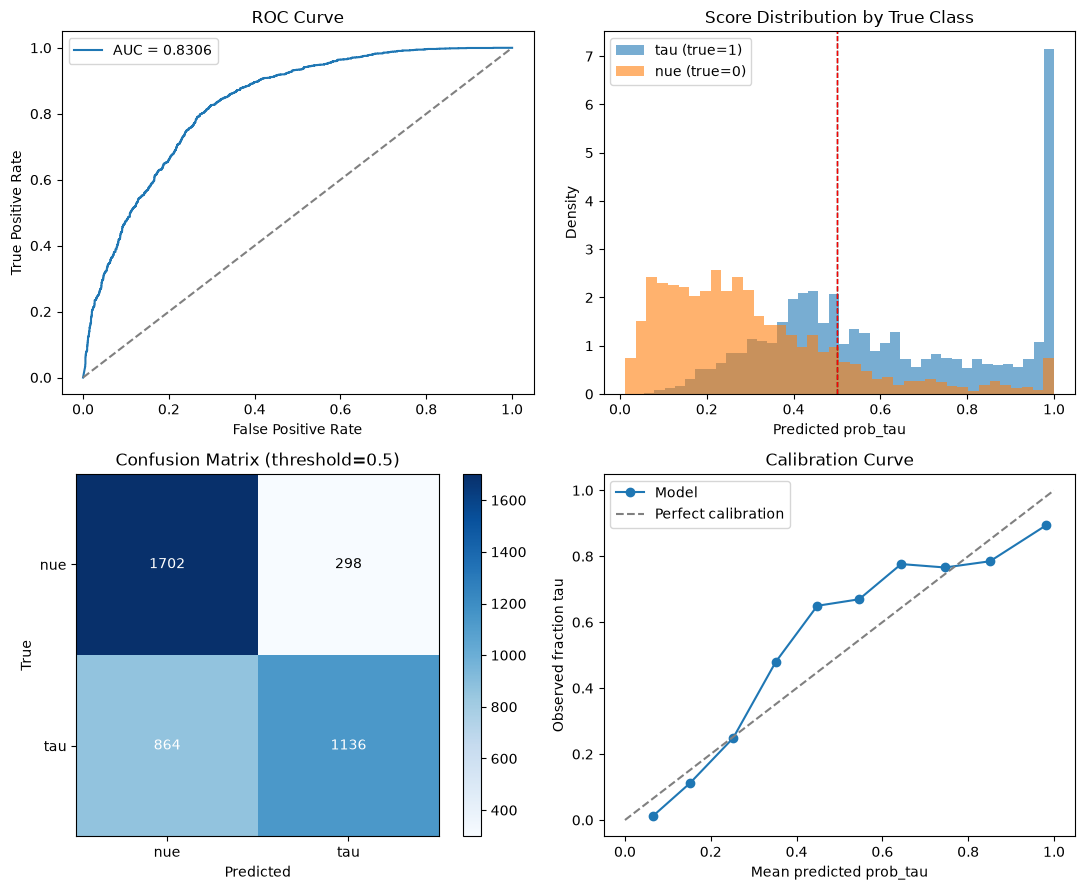

Threshold 0.50  |  Tau recovery (recall): 0.5680  |  Nue rejection: 0.8510


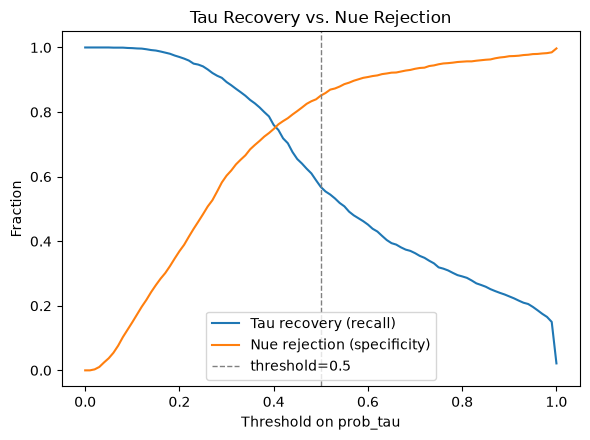

In [5]:
df = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/infer_GAT/scores.csv")
threshold = 0.5
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")

# single threshold check
threshold = 0.5
recovery = tau_recovery(y_true, y_prob, threshold)
rejection = nue_rejection(y_true, y_prob, threshold)
print(f"Threshold {threshold:.2f}  |  Tau recovery (recall): {recovery:.4f}  |  Nue rejection: {rejection:.4f}")


thresholds = np.linspace(0.0, 1.0, 101)
recoveries = [tau_recovery(y_true, y_prob, t) for t in thresholds]
rejections = [nue_rejection(y_true, y_prob, t) for t in thresholds]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.axvline(threshold, color="gray", linestyle="--", linewidth=1, label=f"threshold={threshold}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection")
ax.legend()
plt.tight_layout()
plt.show()

AUC:        0.8238
Accuracy:   0.6587
Precision:  0.8462
Recall:     0.3880
F1:         0.5321
Brier:      0.1831
Log loss:   0.5980
Confusion matrix [tn=1859, fp=141, fn=1224, tp=776]
  Specificity (TNR): 0.9295
  FPR:               0.0705


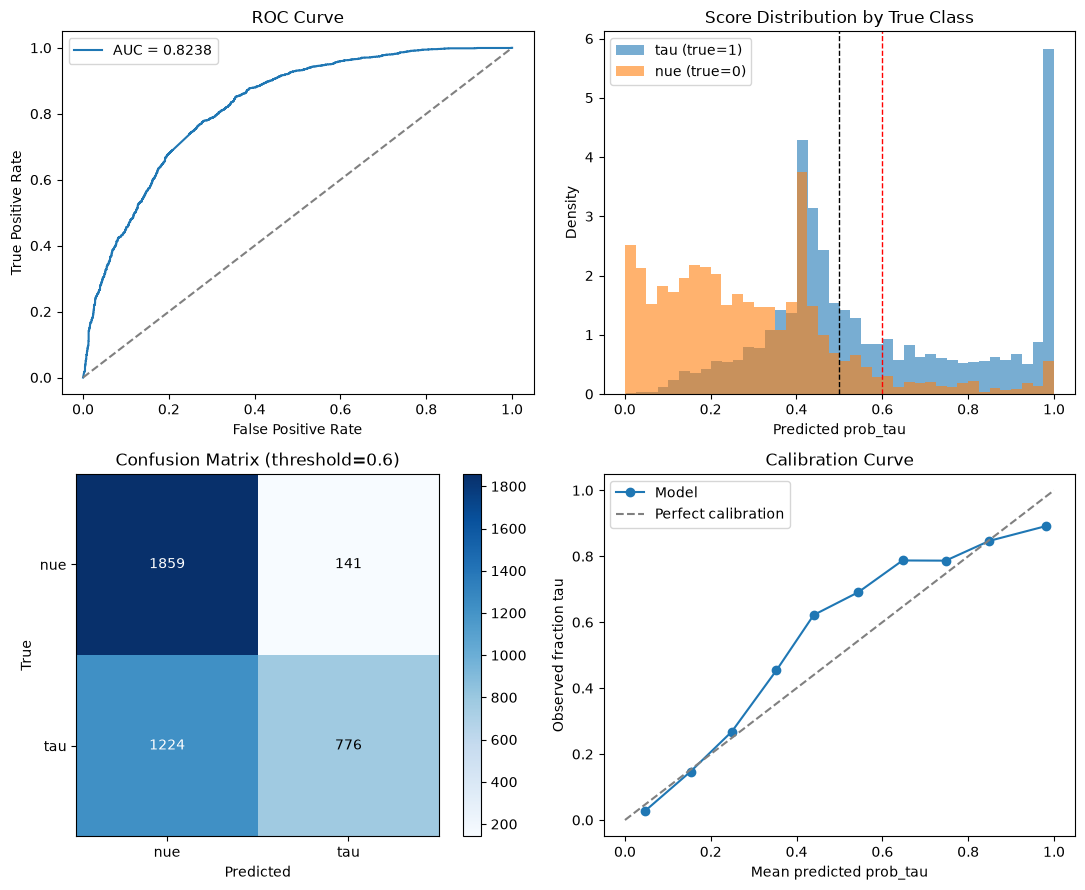

Threshold 0.50  |  Tau recovery (recall): 0.4975  |  Nue rejection: 0.8805


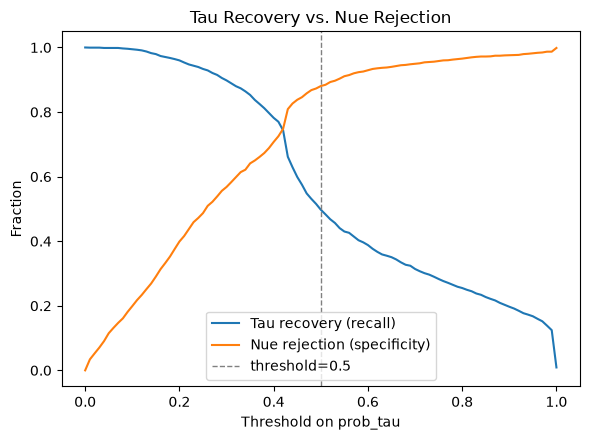

In [6]:
df = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/infer_GAT_0p5dropout_weightdecay5e4/scores.csv")
threshold = 0.6
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")

# single threshold check
threshold = 0.5
recovery = tau_recovery(y_true, y_prob, threshold)
rejection = nue_rejection(y_true, y_prob, threshold)
print(f"Threshold {threshold:.2f}  |  Tau recovery (recall): {recovery:.4f}  |  Nue rejection: {rejection:.4f}")


thresholds = np.linspace(0.0, 1.0, 101)
recoveries = [tau_recovery(y_true, y_prob, t) for t in thresholds]
rejections = [nue_rejection(y_true, y_prob, t) for t in thresholds]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.axvline(threshold, color="gray", linestyle="--", linewidth=1, label=f"threshold={threshold}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection")
ax.legend()
plt.tight_layout()
plt.show()

alpha=0.9  ->  best threshold: 0.9780
  Tau recovery:  0.1410
  Nue rejection: 0.9870
  Weighted score: 0.9024


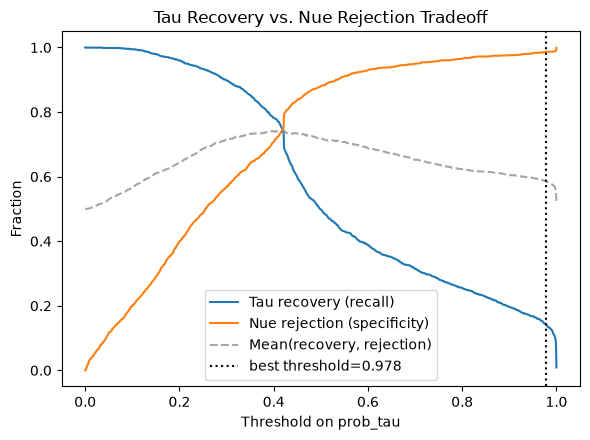

In [7]:
thresholds = np.linspace(0.0, 1.0, 1001)
recoveries = np.array([tau_recovery(y_true, y_prob, t) for t in thresholds])
rejections = np.array([nue_rejection(y_true, y_prob, t) for t in thresholds])

alpha = 0.9

weighted_score = alpha * rejections + (1 - alpha) * recoveries
best_idx = np.argmax(weighted_score)
best_threshold = thresholds[best_idx]

print(f"alpha={alpha}  ->  best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")
print(f"  Weighted score: {weighted_score[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.plot(thresholds, combined / 2, "--", color="gray", alpha=0.7, label="Mean(recovery, rejection)")
ax.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
           label=f"best threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()

AUC:        0.8340
Accuracy:   0.7372
Precision:  0.8013
Recall:     0.6310
F1:         0.7060
Brier:      0.1763
Log loss:   0.6047
Confusion matrix [tn=1687, fp=313, fn=738, tp=1262]
  Specificity (TNR): 0.8435
  FPR:               0.1565


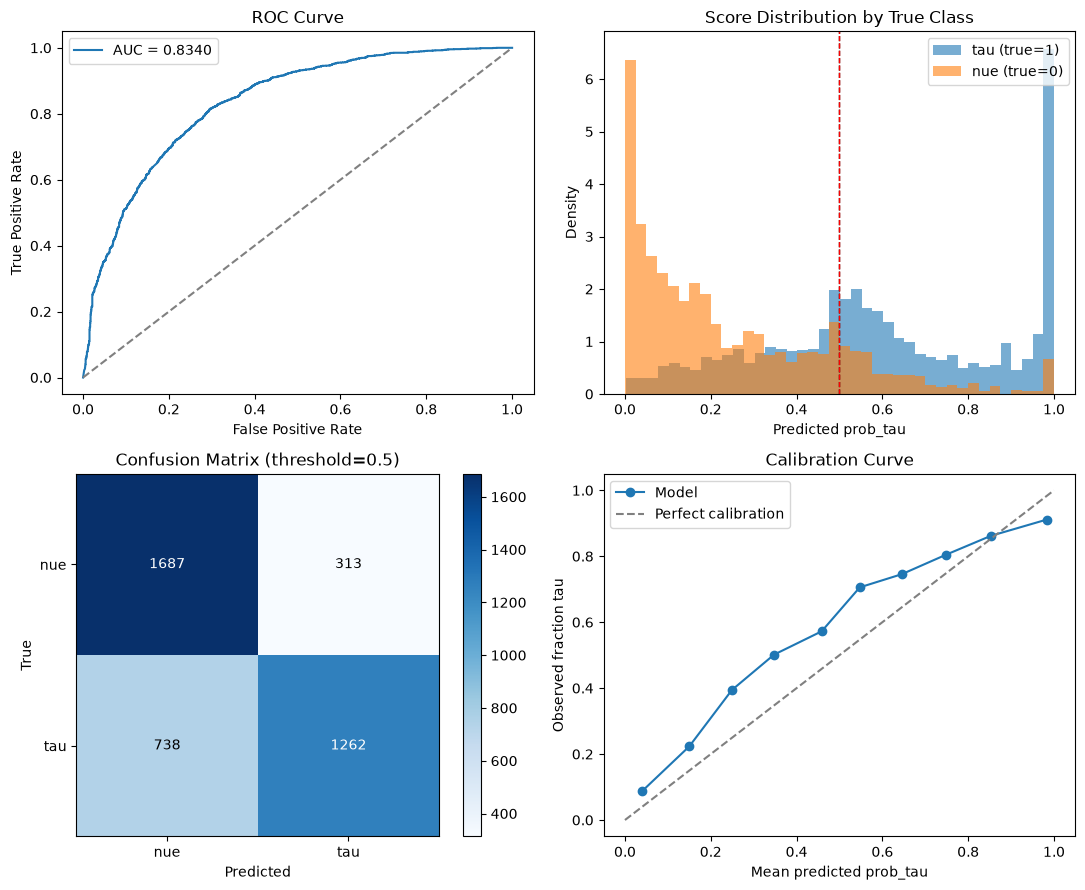

Best threshold: 0.3350
  Tau recovery:  0.8150
  Nue rejection: 0.7050
  Sum:           1.5200


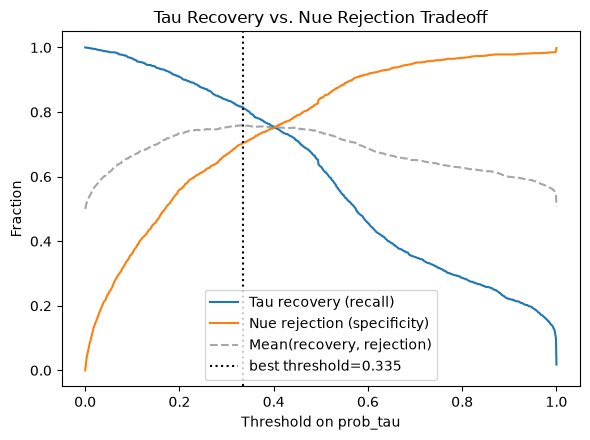

alpha=0.7  ->  best threshold: 0.5720
  Tau recovery:  0.5050
  Nue rejection: 0.9060
 alpha  threshold   recovery  rejection
  0.50     0.3350     0.8150     0.7050
  0.60     0.4850     0.6665     0.8205
  0.70     0.5720     0.5050     0.9060
  0.80     0.8570     0.2575     0.9770
  0.90     0.8700     0.2490     0.9785
  1.00     1.0000     0.0180     0.9980


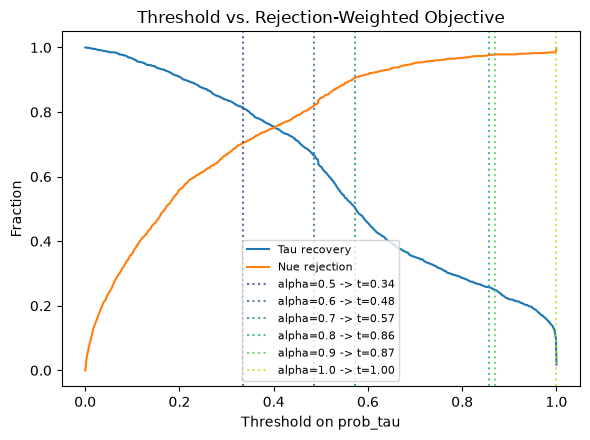

In [9]:
df = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/infer_GAT_0p3dropout_weightdecay5e4_64batchsize/scores.csv")
threshold = 0.5
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")


thresholds = np.linspace(0.0, 1.0, 1001)
recoveries = np.array([tau_recovery(y_true, y_prob, t) for t in thresholds])
rejections = np.array([nue_rejection(y_true, y_prob, t) for t in thresholds])

combined = recoveries + rejections  # maximize this
best_idx = np.argmax(combined)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")
print(f"  Sum:           {combined[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.plot(thresholds, combined / 2, "--", color="gray", alpha=0.7, label="Mean(recovery, rejection)")
ax.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
           label=f"best threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()


alpha = 0.7  # weight on nue rejection; (1-alpha) on tau recovery. alpha=0.5 == unweighted.

weighted_score = alpha * rejections + (1 - alpha) * recoveries
best_idx = np.argmax(weighted_score)
best_threshold = thresholds[best_idx]

print(f"alpha={alpha}  ->  best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")

alphas = np.linspace(0.5, 1.0, 6)
print(f"{'alpha':>6} {'threshold':>10} {'recovery':>10} {'rejection':>10}")
for a in alphas:
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    print(f"{a:6.2f} {thresholds[idx]:10.4f} {recoveries[idx]:10.4f} {rejections[idx]:10.4f}")


fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery")
ax.plot(thresholds, rejections, label="Nue rejection")
for a, color in zip(alphas, plt.cm.viridis(np.linspace(0.2, 0.9, len(alphas)))):
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    ax.axvline(thresholds[idx], color=color, linestyle=":", alpha=0.8,
               label=f"alpha={a} -> t={thresholds[idx]:.2f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Threshold vs. Rejection-Weighted Objective")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

AUC:        0.6888
Accuracy:   0.5927
Precision:  0.8918
Recall:     0.3096
F1:         0.4597
Brier:      0.2445
Log loss:   0.7542
Confusion matrix [tn=7548, fp=378, fn=6950, tp=3117]
  Specificity (TNR): 0.9523
  FPR:               0.0477


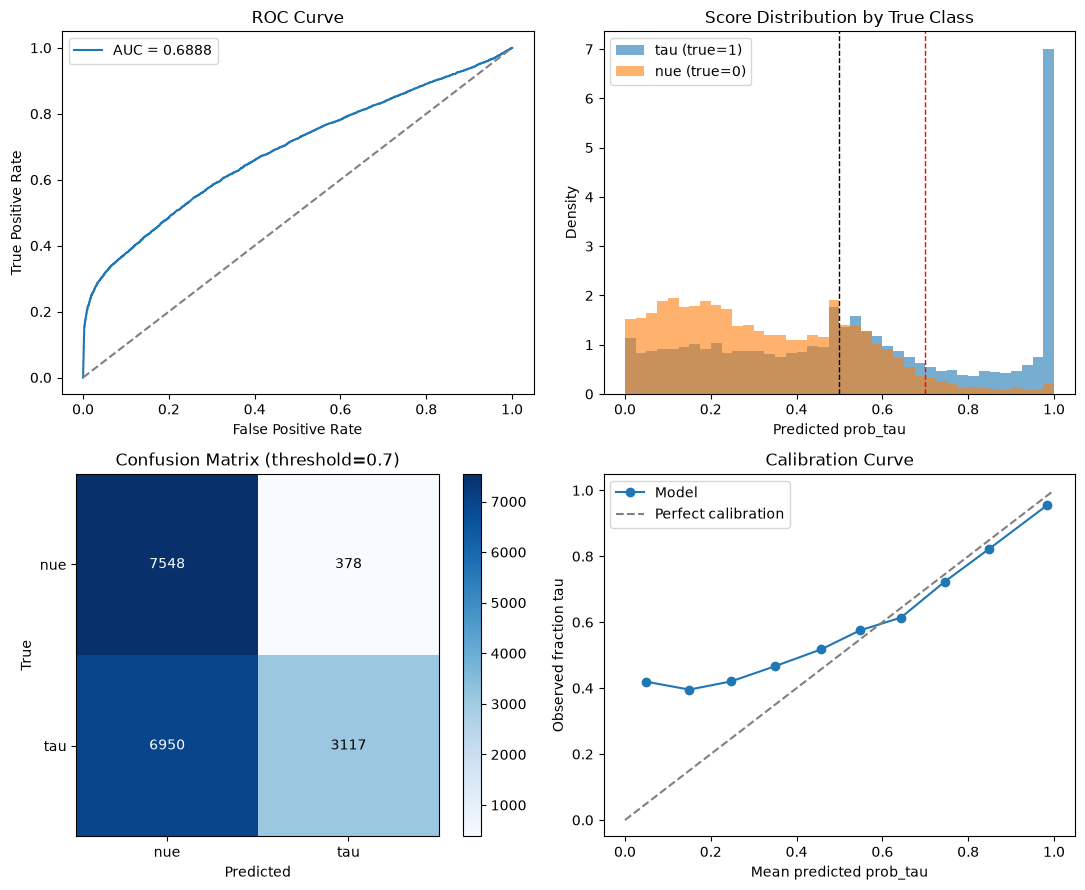

Best threshold: 0.5250
  Tau recovery:  0.4914
  Nue rejection: 0.7964
  Sum:           1.2878


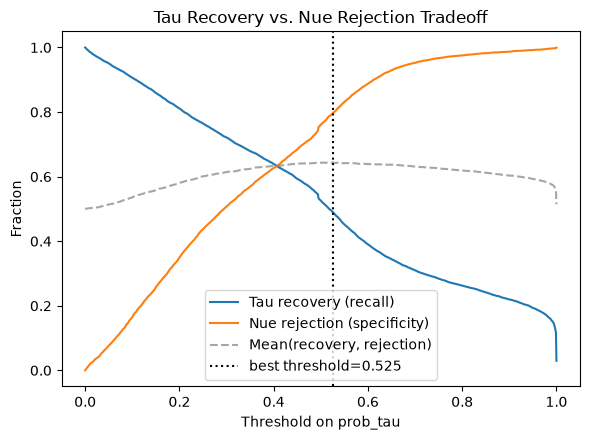

alpha=0.7  ->  best threshold: 0.7430
  Tau recovery:  0.2882
  Nue rejection: 0.9658
 alpha  threshold   recovery  rejection
  0.50     0.5250     0.4914     0.7964
  0.60     0.6620     0.3357     0.9372
  0.70     0.7430     0.2882     0.9658
  0.80     0.8400     0.2465     0.9816
  0.90     0.9810     0.1682     0.9957
  1.00     1.0000     0.0295     0.9995


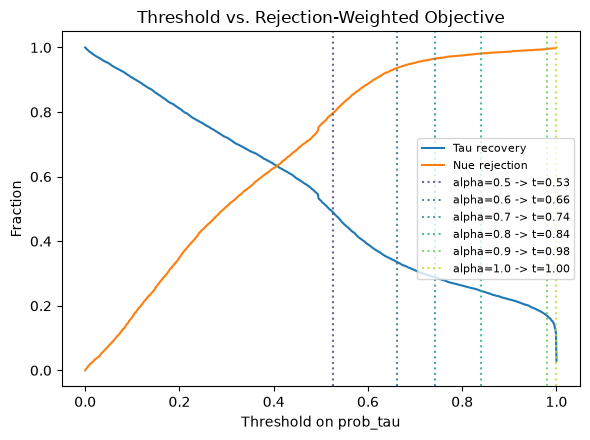

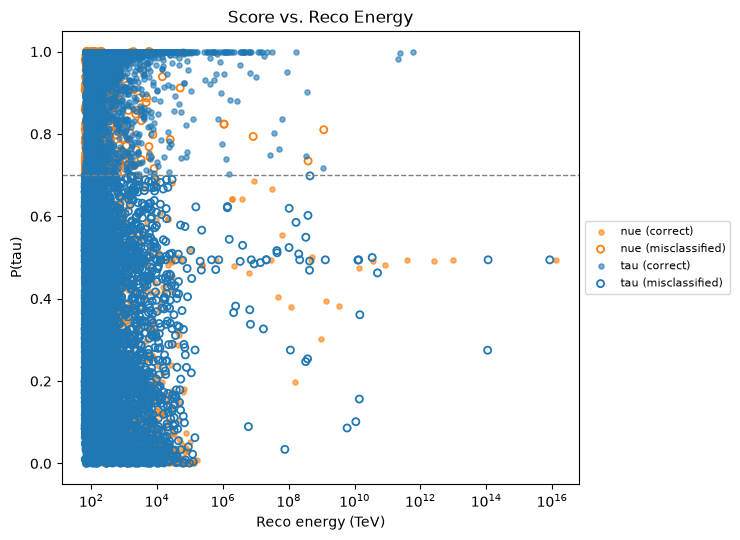


             bin range (TeV)   n_tau   n_nue      AUC   recovery  rejection
[     65.0,      74.7)    1435    1564   0.6610     0.2174     0.9450
[     74.7,      89.7)    1497    1502   0.6656     0.2017     0.9547
[     89.7,     118.8)    1494    1504   0.6663     0.2356     0.9548
[    118.8,     208.4)    1609    1390   0.6913     0.2809     0.9597
[    208.4,     719.5)    1835    1164   0.7023     0.3460     0.9553
[    719.5, 13087582000000000.0)    2197     801   0.7867     0.4843     0.9401


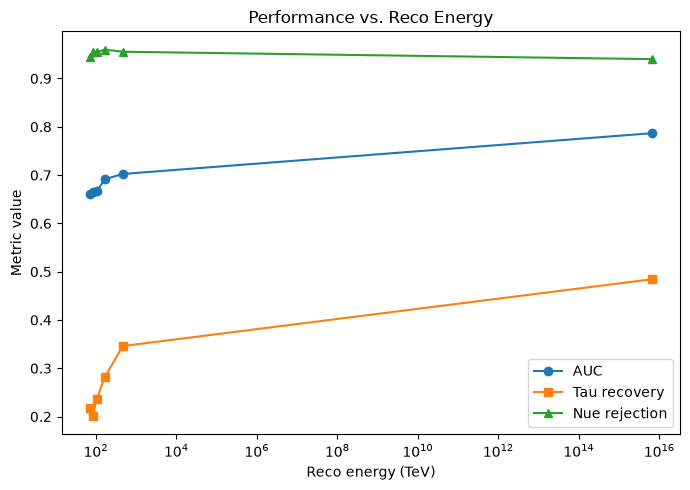

In [ ]:
df = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/infer_GAT_0p3dropout_weightdecay5e4_64batchsize_all_ftp/scores.csv")
threshold = 0.7
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")


thresholds = np.linspace(0.0, 1.0, 1001)
recoveries = np.array([tau_recovery(y_true, y_prob, t) for t in thresholds])
rejections = np.array([nue_rejection(y_true, y_prob, t) for t in thresholds])

combined = recoveries + rejections  # maximize this
best_idx = np.argmax(combined)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")
print(f"  Sum:           {combined[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.plot(thresholds, combined / 2, "--", color="gray", alpha=0.7, label="Mean(recovery, rejection)")
ax.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
           label=f"best threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()


alpha = 0.7  # weight on nue rejection; (1-alpha) on tau recovery. alpha=0.5 == unweighted.

weighted_score = alpha * rejections + (1 - alpha) * recoveries
best_idx = np.argmax(weighted_score)
best_threshold = thresholds[best_idx]

print(f"alpha={alpha}  ->  best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")

alphas = np.linspace(0.5, 1.0, 6)
print(f"{'alpha':>6} {'threshold':>10} {'recovery':>10} {'rejection':>10}")
for a in alphas:
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    print(f"{a:6.2f} {thresholds[idx]:10.4f} {recoveries[idx]:10.4f} {rejections[idx]:10.4f}")


fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery")
ax.plot(thresholds, rejections, label="Nue rejection")
for a, color in zip(alphas, plt.cm.viridis(np.linspace(0.2, 0.9, len(alphas)))):
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    ax.axvline(thresholds[idx], color=color, linestyle=":", alpha=0.8,
               label=f"alpha={a} -> t={thresholds[idx]:.2f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Threshold vs. Rejection-Weighted Objective")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()


energy = df["reco_energy_tev"].values

# --- 1. Score vs. energy scatter, colored by true class + misclassification ---
correct = y_pred == y_true

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for label, name, color in [(0, "nue", "tab:orange"), (1, "tau", "tab:blue")]:
    mask = y_true == label
    ax.scatter(energy[mask & correct], y_prob[mask & correct],
               s=14, color=color, alpha=0.6, label=f"{name} (correct)")
    ax.scatter(energy[mask & ~correct], y_prob[mask & ~correct],
               s=26, facecolors="none", edgecolors=color, linewidths=1.3,
               label=f"{name} (misclassified)")
ax.axhline(threshold, color="gray", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("P(tau)")
ax.set_title("Score vs. Reco Energy")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# --- 2. Energy-binned AUC / recovery / rejection ---
n_bins = 6
bin_edges = np.quantile(energy, np.linspace(0, 1, n_bins + 1))
bin_edges[0], bin_edges[-1] = bin_edges[0] - 1e-6, bin_edges[-1] + 1e-6

print(f"\n{'bin range (TeV)':>28} {'n_tau':>7} {'n_nue':>7} {'AUC':>8} "
      f"{'recovery':>10} {'rejection':>10}")
bin_results = []
for i in range(n_bins):
    mask = (energy >= bin_edges[i]) & (energy < bin_edges[i + 1])
    n_tau = int((y_true[mask] == 1).sum())
    n_nue = int((y_true[mask] == 0).sum())
    auc_bin = roc_auc_score(y_true[mask], y_prob[mask]) if len(np.unique(y_true[mask])) >= 2 else float("nan")
    rec_bin = tau_recovery(y_true[mask], y_prob[mask], threshold)
    rej_bin = nue_rejection(y_true[mask], y_prob[mask], threshold)
    bin_results.append({"lo": bin_edges[i], "hi": bin_edges[i+1], "auc": auc_bin,
                         "recovery": rec_bin, "rejection": rej_bin})
    print(f"[{bin_edges[i]:9.1f}, {bin_edges[i+1]:9.1f}) {n_tau:7d} {n_nue:7d} "
          f"{auc_bin:8.4f} {rec_bin:10.4f} {rej_bin:10.4f}")

bin_centers = [(r["lo"] + r["hi"]) / 2 for r in bin_results]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bin_centers, [r["auc"] for r in bin_results], "o-", label="AUC")
ax.plot(bin_centers, [r["recovery"] for r in bin_results], "s-", label="Tau recovery")
ax.plot(bin_centers, [r["rejection"] for r in bin_results], "^-", label="Nue rejection")
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("Metric value")
ax.set_title("Performance vs. Reco Energy")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
df_clean = df[df["reco_energy_tev"] < 1e5].copy()  # drop the corrupted event(s)
energy = df_clean["reco_energy_tev"].values
y_true_c = df_clean["true_label"].values
y_prob_c = df_clean["prob_tau"].values

fixed_edges = [65, 100, 200, 500, 1000, 2500, 6000, np.inf]
print(f"{'bin range (TeV)':>22} {'n_tau':>7} {'n_nue':>7} {'tau frac':>9} {'AUC':>8}")
for i in range(len(fixed_edges) - 1):
    mask = (energy >= fixed_edges[i]) & (energy < fixed_edges[i + 1])
    n_tau = int((y_true_c[mask] == 1).sum())
    n_nue = int((y_true_c[mask] == 0).sum())
    tau_frac = n_tau / max(n_tau + n_nue, 1)
    auc_bin = roc_auc_score(y_true_c[mask], y_prob_c[mask]) if len(np.unique(y_true_c[mask])) >= 2 else float("nan")
    print(f"[{fixed_edges[i]:8.1f}, {fixed_edges[i+1]:8.1f}) {n_tau:7d} {n_nue:7d} {tau_frac:9.3f} {auc_bin:8.4f}")

       bin range (TeV)   n_tau   n_nue  tau frac      AUC
[    65.0,    100.0)    3591    3762     0.488   0.6630
[   100.0,    200.0)    2358    2130     0.525   0.6854
[   200.0,    500.0)    1517    1007     0.601   0.6977
[   500.0,   1000.0)     669     364     0.648   0.7263
[  1000.0,   2500.0)     645     224     0.742   0.7314
[  2500.0,   6000.0)     498     145     0.774   0.7980
[  6000.0,      inf)     652     255     0.719   0.8434


AUC:        0.6965
Accuracy:   0.6309
Precision:  0.8339
Recall:     0.3269
F1:         0.4697
Brier:      0.2316
Log loss:   0.7472
Confusion matrix [tn=9349, fp=651, fn=6731, tp=3269]
  Specificity (TNR): 0.9349
  FPR:               0.0651


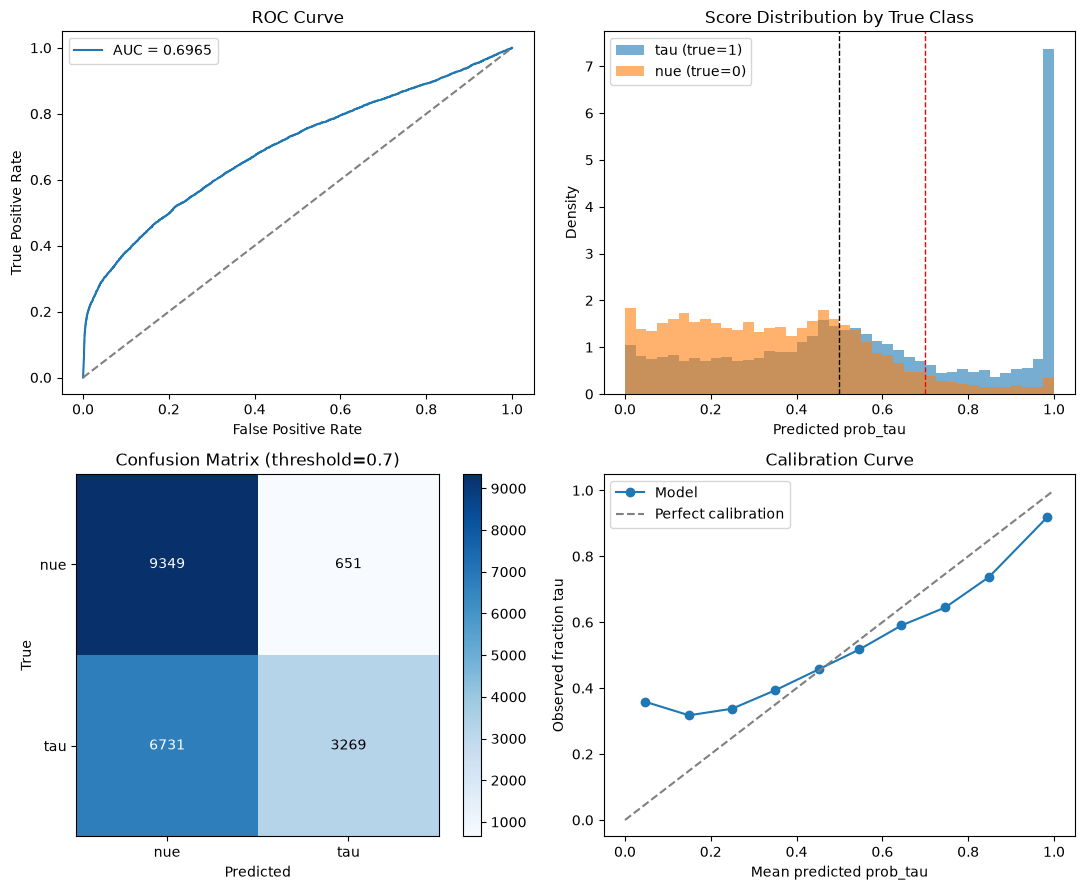

Best threshold: 0.5170
  Tau recovery:  0.5214
  Nue rejection: 0.7820
  Sum:           1.3034


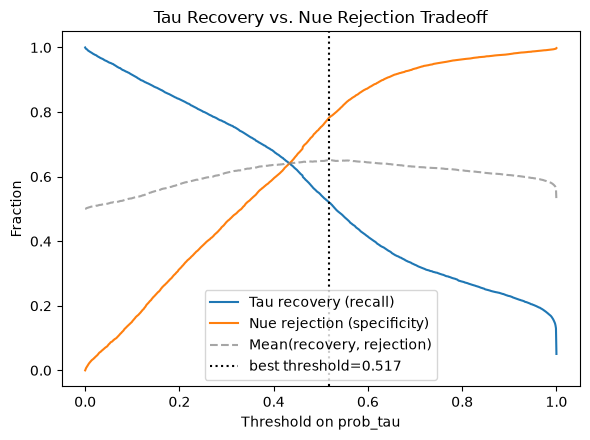

alpha=0.7  ->  best threshold: 0.7840
  Tau recovery:  0.2841
  Nue rejection: 0.9603
 alpha  threshold   recovery  rejection
  0.50     0.5170     0.5214     0.7820
  0.60     0.6410     0.3733     0.9063
  0.70     0.7840     0.2841     0.9603
  0.80     0.9490     0.2041     0.9877
  0.90     0.9880     0.1688     0.9936
  1.00     1.0000     0.0508     0.9981


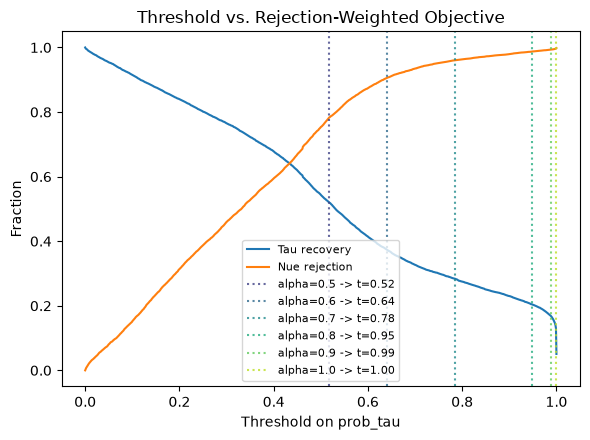

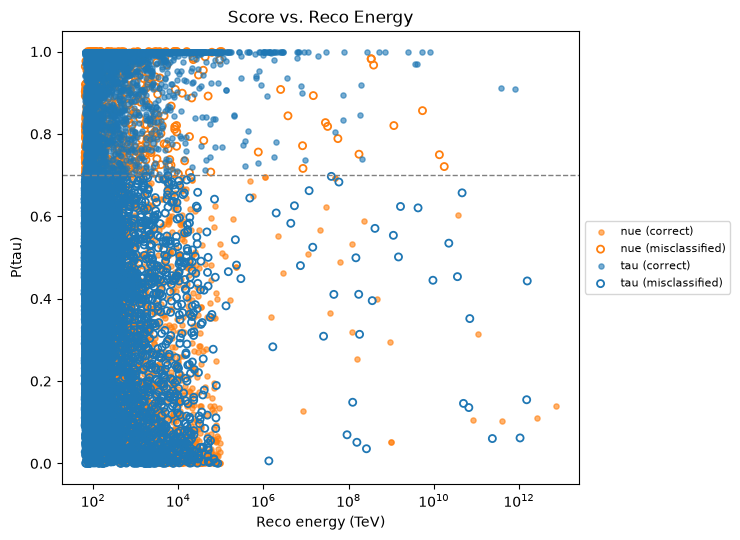


             bin range (TeV)   n_tau   n_nue      AUC   recovery  rejection
[     65.0,      75.2)    1478    1856   0.6557     0.1922     0.9472
[     75.2,      91.2)    1528    1805   0.6807     0.2277     0.9529
[     91.2,     121.0)    1612    1721   0.6860     0.2457     0.9483
[    121.0,     219.8)    1612    1721   0.6653     0.2767     0.9396
[    219.8,     865.7)    1768    1565   0.7208     0.4038     0.9176
[    865.7, 7397392000000.0)    2002    1331   0.7743     0.5400     0.8903


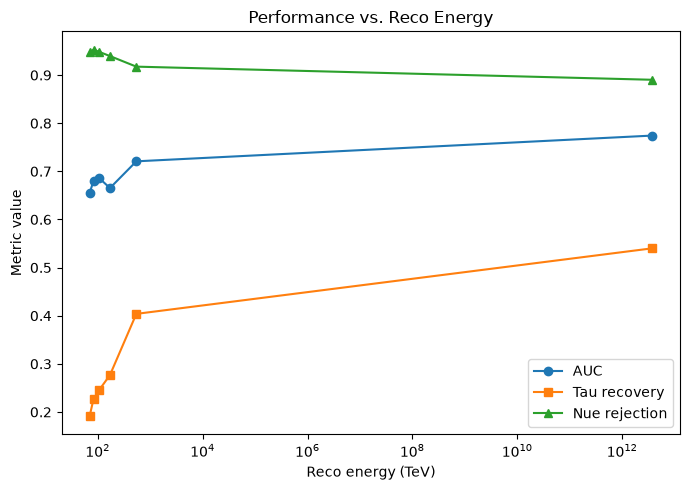

       bin range (TeV)   n_tau   n_nue  tau frac      AUC
[    65.0,    100.0)    3615    4354     0.454   0.6682
[   100.0,    200.0)    2430    2573     0.486   0.6767
[   200.0,    500.0)    1416    1308     0.520   0.7211
[   500.0,   1000.0)     685     525     0.566   0.7132
[  1000.0,   2500.0)     643     396     0.619   0.7428
[  2500.0,   6000.0)     441     280     0.612   0.7719
[  6000.0,      inf)     636     511     0.554   0.8093


In [3]:
df = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/infer_GAT_0p3dropout_weightdecay5e4_64batchsize_a0p3valfrav/scores.csv")
threshold = 0.7
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")


thresholds = np.linspace(0.0, 1.0, 1001)
recoveries = np.array([tau_recovery(y_true, y_prob, t) for t in thresholds])
rejections = np.array([nue_rejection(y_true, y_prob, t) for t in thresholds])

combined = recoveries + rejections  # maximize this
best_idx = np.argmax(combined)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")
print(f"  Sum:           {combined[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.plot(thresholds, combined / 2, "--", color="gray", alpha=0.7, label="Mean(recovery, rejection)")
ax.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
           label=f"best threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()


alpha = 0.7  # weight on nue rejection; (1-alpha) on tau recovery. alpha=0.5 == unweighted.

weighted_score = alpha * rejections + (1 - alpha) * recoveries
best_idx = np.argmax(weighted_score)
best_threshold = thresholds[best_idx]

print(f"alpha={alpha}  ->  best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")

alphas = np.linspace(0.5, 1.0, 6)
print(f"{'alpha':>6} {'threshold':>10} {'recovery':>10} {'rejection':>10}")
for a in alphas:
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    print(f"{a:6.2f} {thresholds[idx]:10.4f} {recoveries[idx]:10.4f} {rejections[idx]:10.4f}")


fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery")
ax.plot(thresholds, rejections, label="Nue rejection")
for a, color in zip(alphas, plt.cm.viridis(np.linspace(0.2, 0.9, len(alphas)))):
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    ax.axvline(thresholds[idx], color=color, linestyle=":", alpha=0.8,
               label=f"alpha={a} -> t={thresholds[idx]:.2f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Threshold vs. Rejection-Weighted Objective")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()


energy = df["reco_energy_tev"].values

# --- 1. Score vs. energy scatter, colored by true class + misclassification ---
correct = y_pred == y_true

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for label, name, color in [(0, "nue", "tab:orange"), (1, "tau", "tab:blue")]:
    mask = y_true == label
    ax.scatter(energy[mask & correct], y_prob[mask & correct],
               s=14, color=color, alpha=0.6, label=f"{name} (correct)")
    ax.scatter(energy[mask & ~correct], y_prob[mask & ~correct],
               s=26, facecolors="none", edgecolors=color, linewidths=1.3,
               label=f"{name} (misclassified)")
ax.axhline(threshold, color="gray", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("P(tau)")
ax.set_title("Score vs. Reco Energy")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# --- 2. Energy-binned AUC / recovery / rejection ---
n_bins = 6
bin_edges = np.quantile(energy, np.linspace(0, 1, n_bins + 1))
bin_edges[0], bin_edges[-1] = bin_edges[0] - 1e-6, bin_edges[-1] + 1e-6

print(f"\n{'bin range (TeV)':>28} {'n_tau':>7} {'n_nue':>7} {'AUC':>8} "
      f"{'recovery':>10} {'rejection':>10}")
bin_results = []
for i in range(n_bins):
    mask = (energy >= bin_edges[i]) & (energy < bin_edges[i + 1])
    n_tau = int((y_true[mask] == 1).sum())
    n_nue = int((y_true[mask] == 0).sum())
    auc_bin = roc_auc_score(y_true[mask], y_prob[mask]) if len(np.unique(y_true[mask])) >= 2 else float("nan")
    rec_bin = tau_recovery(y_true[mask], y_prob[mask], threshold)
    rej_bin = nue_rejection(y_true[mask], y_prob[mask], threshold)
    bin_results.append({"lo": bin_edges[i], "hi": bin_edges[i+1], "auc": auc_bin,
                         "recovery": rec_bin, "rejection": rej_bin})
    print(f"[{bin_edges[i]:9.1f}, {bin_edges[i+1]:9.1f}) {n_tau:7d} {n_nue:7d} "
          f"{auc_bin:8.4f} {rec_bin:10.4f} {rej_bin:10.4f}")

bin_centers = [(r["lo"] + r["hi"]) / 2 for r in bin_results]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bin_centers, [r["auc"] for r in bin_results], "o-", label="AUC")
ax.plot(bin_centers, [r["recovery"] for r in bin_results], "s-", label="Tau recovery")
ax.plot(bin_centers, [r["rejection"] for r in bin_results], "^-", label="Nue rejection")
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("Metric value")
ax.set_title("Performance vs. Reco Energy")
ax.legend()
plt.tight_layout()
plt.show()

df_clean = df[df["reco_energy_tev"] < 1e5].copy()  # drop the corrupted event(s)
energy = df_clean["reco_energy_tev"].values
y_true_c = df_clean["true_label"].values
y_prob_c = df_clean["prob_tau"].values

fixed_edges = [65, 100, 200, 500, 1000, 2500, 6000, np.inf]
print(f"{'bin range (TeV)':>22} {'n_tau':>7} {'n_nue':>7} {'tau frac':>9} {'AUC':>8}")
for i in range(len(fixed_edges) - 1):
    mask = (energy >= fixed_edges[i]) & (energy < fixed_edges[i + 1])
    n_tau = int((y_true_c[mask] == 1).sum())
    n_nue = int((y_true_c[mask] == 0).sum())
    tau_frac = n_tau / max(n_tau + n_nue, 1)
    auc_bin = roc_auc_score(y_true_c[mask], y_prob_c[mask]) if len(np.unique(y_true_c[mask])) >= 2 else float("nan")
    print(f"[{fixed_edges[i]:8.1f}, {fixed_edges[i+1]:8.1f}) {n_tau:7d} {n_nue:7d} {tau_frac:9.3f} {auc_bin:8.4f}")

AUC:        0.6941
Accuracy:   0.5873
Precision:  0.9528
Recall:     0.1837
F1:         0.3080
Brier:      0.2192
Log loss:   0.6234
Confusion matrix [tn=9909, fp=91, fn=8163, tp=1837]
  Specificity (TNR): 0.9909
  FPR:               0.0091


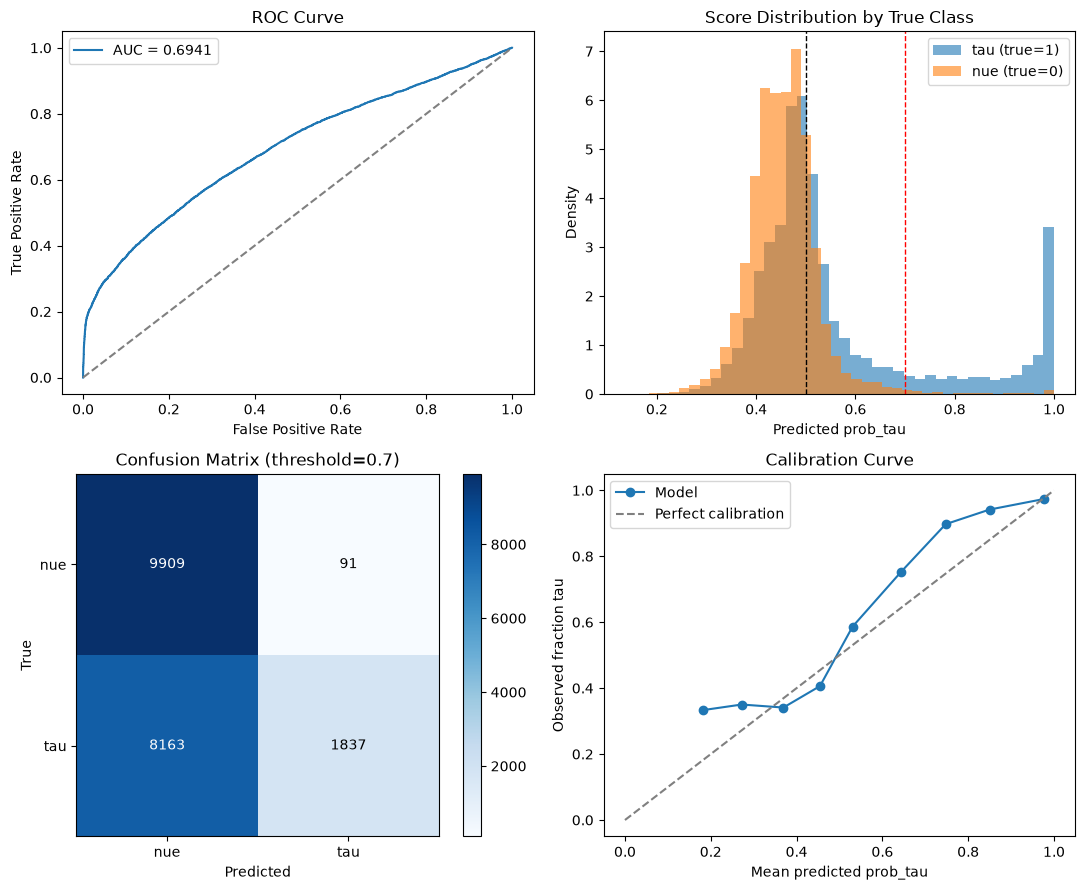

Best threshold: 0.4900
  Tau recovery:  0.5407
  Nue rejection: 0.7470
  Sum:           1.2877


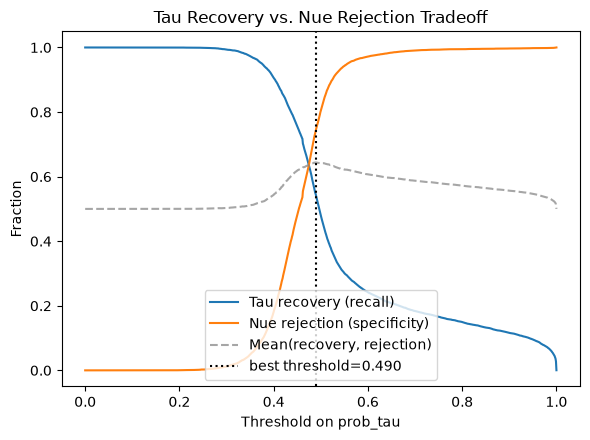

alpha=0.7  ->  best threshold: 0.5730
  Tau recovery:  0.2703
  Nue rejection: 0.9618
 alpha  threshold   recovery  rejection
  0.50     0.4900     0.5407     0.7470
  0.60     0.5270     0.3583     0.9069
  0.70     0.5730     0.2703     0.9618
  0.80     0.6690     0.1988     0.9874
  0.90     0.7300     0.1736     0.9929
  1.00     1.0000     0.0004     1.0000


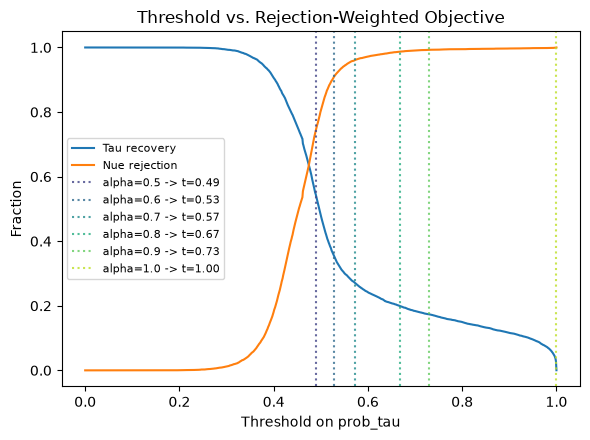

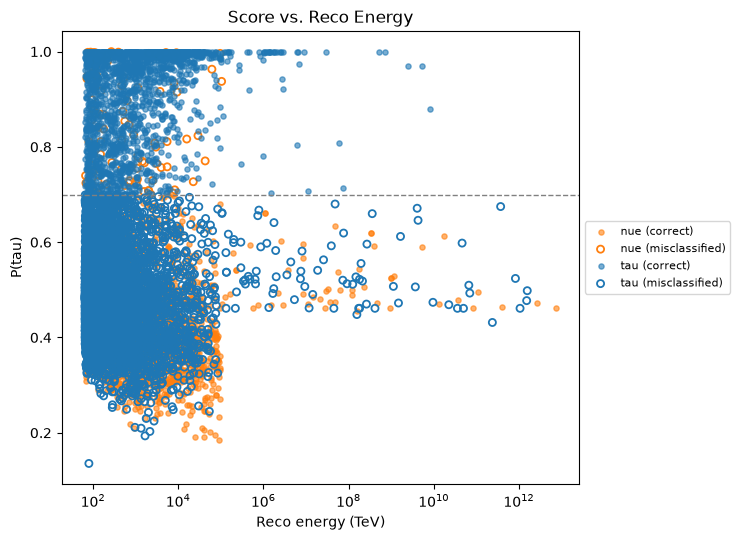


             bin range (TeV)   n_tau   n_nue      AUC   recovery  rejection
[     65.0,      75.2)    1478    1856   0.6463     0.0575     0.9973
[     75.2,      91.2)    1528    1805   0.6676     0.0733     0.9978
[     91.2,     121.0)    1612    1721   0.6759     0.0962     0.9919
[    121.0,     219.8)    1612    1721   0.6616     0.1266     0.9913
[    219.8,     865.7)    1768    1565   0.7234     0.2455     0.9898
[    865.7, 7397392000000.0)    2002    1331   0.7802     0.4231     0.9722


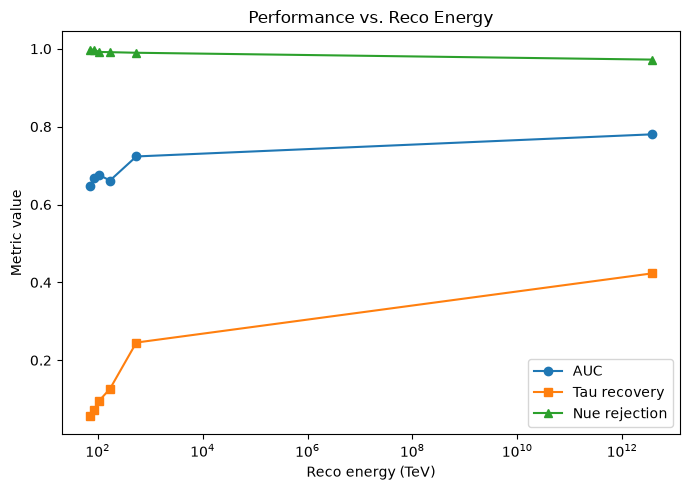

       bin range (TeV)   n_tau   n_nue  tau frac      AUC
[    65.0,    100.0)    3615    4354     0.454   0.6567
[   100.0,    200.0)    2430    2573     0.486   0.6706
[   200.0,    500.0)    1416    1308     0.520   0.7209
[   500.0,   1000.0)     685     525     0.566   0.7184
[  1000.0,   2500.0)     643     396     0.619   0.7473
[  2500.0,   6000.0)     441     280     0.612   0.7839
[  6000.0,      inf)     636     511     0.554   0.8160


In [4]:
df = pd.read_csv("trained_model/infer_GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss3p/scores.csv")
threshold = 0.7
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")


thresholds = np.linspace(0.0, 1.0, 1001)
recoveries = np.array([tau_recovery(y_true, y_prob, t) for t in thresholds])
rejections = np.array([nue_rejection(y_true, y_prob, t) for t in thresholds])

combined = recoveries + rejections  # maximize this
best_idx = np.argmax(combined)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")
print(f"  Sum:           {combined[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.plot(thresholds, combined / 2, "--", color="gray", alpha=0.7, label="Mean(recovery, rejection)")
ax.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
           label=f"best threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()


alpha = 0.7  # weight on nue rejection; (1-alpha) on tau recovery. alpha=0.5 == unweighted.

weighted_score = alpha * rejections + (1 - alpha) * recoveries
best_idx = np.argmax(weighted_score)
best_threshold = thresholds[best_idx]

print(f"alpha={alpha}  ->  best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")

alphas = np.linspace(0.5, 1.0, 6)
print(f"{'alpha':>6} {'threshold':>10} {'recovery':>10} {'rejection':>10}")
for a in alphas:
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    print(f"{a:6.2f} {thresholds[idx]:10.4f} {recoveries[idx]:10.4f} {rejections[idx]:10.4f}")


fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery")
ax.plot(thresholds, rejections, label="Nue rejection")
for a, color in zip(alphas, plt.cm.viridis(np.linspace(0.2, 0.9, len(alphas)))):
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    ax.axvline(thresholds[idx], color=color, linestyle=":", alpha=0.8,
               label=f"alpha={a} -> t={thresholds[idx]:.2f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Threshold vs. Rejection-Weighted Objective")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()


energy = df["reco_energy_tev"].values

# --- 1. Score vs. energy scatter, colored by true class + misclassification ---
correct = y_pred == y_true

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for label, name, color in [(0, "nue", "tab:orange"), (1, "tau", "tab:blue")]:
    mask = y_true == label
    ax.scatter(energy[mask & correct], y_prob[mask & correct],
               s=14, color=color, alpha=0.6, label=f"{name} (correct)")
    ax.scatter(energy[mask & ~correct], y_prob[mask & ~correct],
               s=26, facecolors="none", edgecolors=color, linewidths=1.3,
               label=f"{name} (misclassified)")
ax.axhline(threshold, color="gray", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("P(tau)")
ax.set_title("Score vs. Reco Energy")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# --- 2. Energy-binned AUC / recovery / rejection ---
n_bins = 6
bin_edges = np.quantile(energy, np.linspace(0, 1, n_bins + 1))
bin_edges[0], bin_edges[-1] = bin_edges[0] - 1e-6, bin_edges[-1] + 1e-6

print(f"\n{'bin range (TeV)':>28} {'n_tau':>7} {'n_nue':>7} {'AUC':>8} "
      f"{'recovery':>10} {'rejection':>10}")
bin_results = []
for i in range(n_bins):
    mask = (energy >= bin_edges[i]) & (energy < bin_edges[i + 1])
    n_tau = int((y_true[mask] == 1).sum())
    n_nue = int((y_true[mask] == 0).sum())
    auc_bin = roc_auc_score(y_true[mask], y_prob[mask]) if len(np.unique(y_true[mask])) >= 2 else float("nan")
    rec_bin = tau_recovery(y_true[mask], y_prob[mask], threshold)
    rej_bin = nue_rejection(y_true[mask], y_prob[mask], threshold)
    bin_results.append({"lo": bin_edges[i], "hi": bin_edges[i+1], "auc": auc_bin,
                         "recovery": rec_bin, "rejection": rej_bin})
    print(f"[{bin_edges[i]:9.1f}, {bin_edges[i+1]:9.1f}) {n_tau:7d} {n_nue:7d} "
          f"{auc_bin:8.4f} {rec_bin:10.4f} {rej_bin:10.4f}")

bin_centers = [(r["lo"] + r["hi"]) / 2 for r in bin_results]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bin_centers, [r["auc"] for r in bin_results], "o-", label="AUC")
ax.plot(bin_centers, [r["recovery"] for r in bin_results], "s-", label="Tau recovery")
ax.plot(bin_centers, [r["rejection"] for r in bin_results], "^-", label="Nue rejection")
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("Metric value")
ax.set_title("Performance vs. Reco Energy")
ax.legend()
plt.tight_layout()
plt.show()

df_clean = df[df["reco_energy_tev"] < 1e5].copy()  # drop the corrupted event(s)
energy = df_clean["reco_energy_tev"].values
y_true_c = df_clean["true_label"].values
y_prob_c = df_clean["prob_tau"].values

fixed_edges = [65, 100, 200, 500, 1000, 2500, 6000, np.inf]
print(f"{'bin range (TeV)':>22} {'n_tau':>7} {'n_nue':>7} {'tau frac':>9} {'AUC':>8}")
for i in range(len(fixed_edges) - 1):
    mask = (energy >= fixed_edges[i]) & (energy < fixed_edges[i + 1])
    n_tau = int((y_true_c[mask] == 1).sum())
    n_nue = int((y_true_c[mask] == 0).sum())
    tau_frac = n_tau / max(n_tau + n_nue, 1)
    auc_bin = roc_auc_score(y_true_c[mask], y_prob_c[mask]) if len(np.unique(y_true_c[mask])) >= 2 else float("nan")
    print(f"[{fixed_edges[i]:8.1f}, {fixed_edges[i+1]:8.1f}) {n_tau:7d} {n_nue:7d} {tau_frac:9.3f} {auc_bin:8.4f}")

AUC:        0.6982
Accuracy:   0.5926
Precision:  0.9431
Recall:     0.1971
F1:         0.3261
Brier:      0.2165
Log loss:   0.6226
Confusion matrix [tn=9881, fp=119, fn=8029, tp=1971]
  Specificity (TNR): 0.9881
  FPR:               0.0119


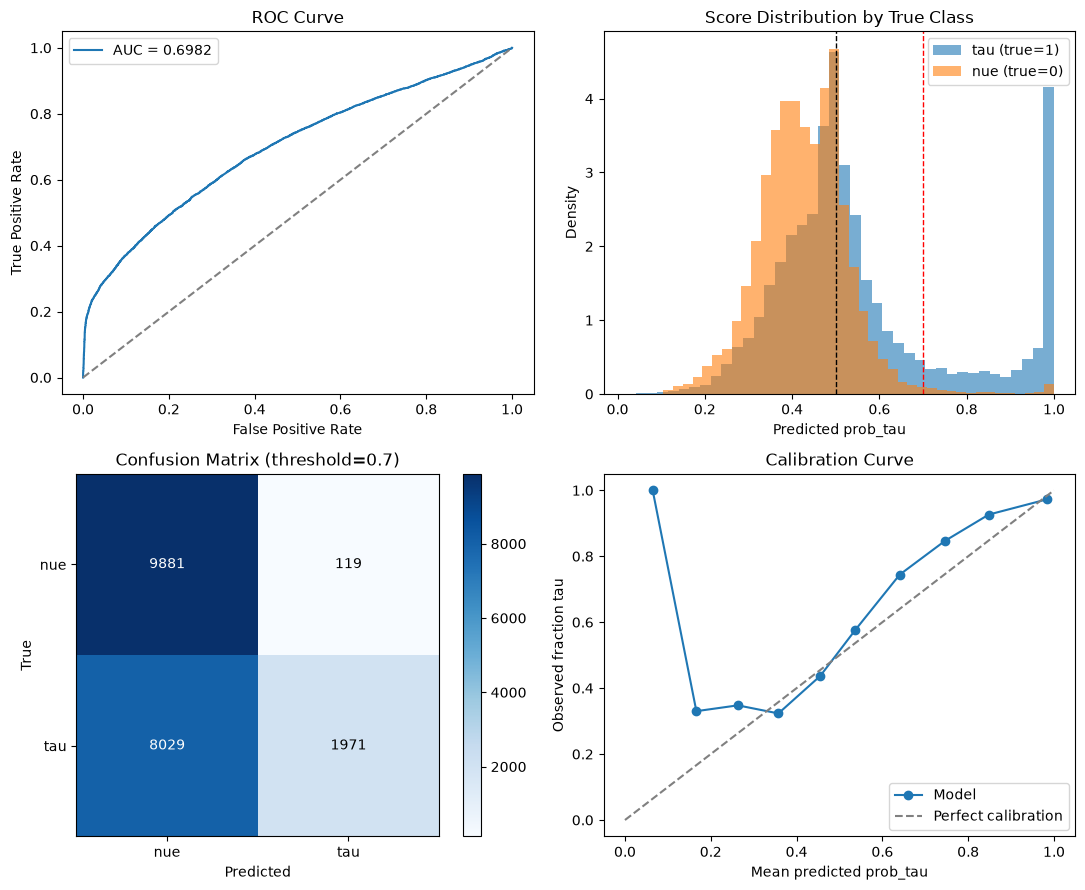

Best threshold: 0.4980
  Tau recovery:  0.5060
  Nue rejection: 0.7878
  Sum:           1.2938


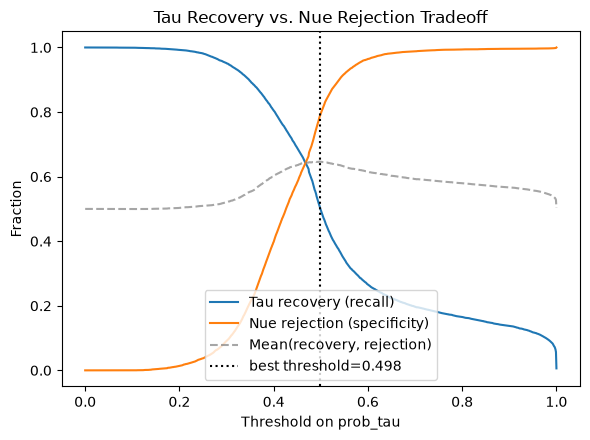

alpha=0.7  ->  best threshold: 0.6360
  Tau recovery:  0.2340
  Nue rejection: 0.9794
 alpha  threshold   recovery  rejection
  0.50     0.4980     0.5060     0.7878
  0.60     0.5430     0.3615     0.9079
  0.70     0.6360     0.2340     0.9794
  0.80     0.6590     0.2186     0.9838
  0.90     0.7630     0.1755     0.9930
  1.00     1.0000     0.0061     1.0000


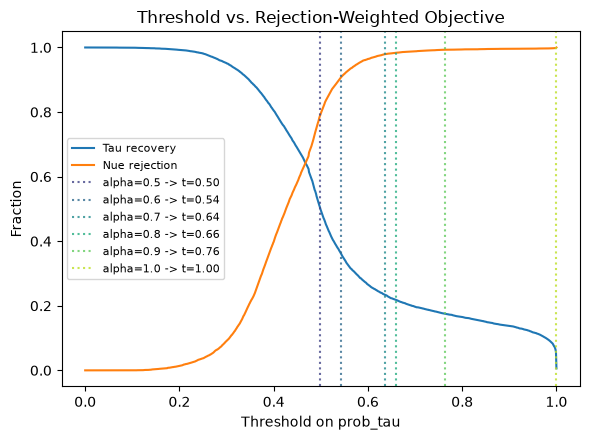

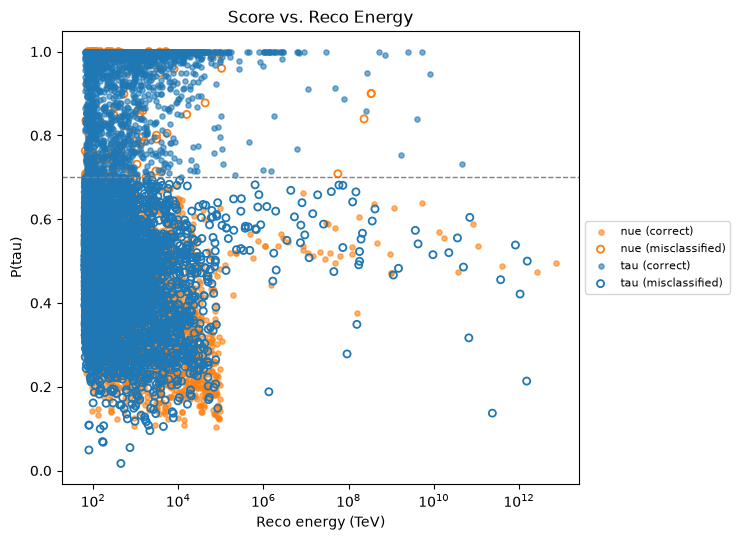


             bin range (TeV)   n_tau   n_nue      AUC   recovery  rejection
[     65.0,      75.2)    1478    1856   0.6611     0.0893     0.9952
[     75.2,      91.2)    1528    1805   0.6753     0.0969     0.9922
[     91.2,     121.0)    1612    1721   0.6826     0.1278     0.9866
[    121.0,     219.8)    1612    1721   0.6690     0.1470     0.9895
[    219.8,     865.7)    1768    1565   0.7213     0.2381     0.9872
[    865.7, 7397392000000.0)    2002    1331   0.7788     0.4131     0.9737


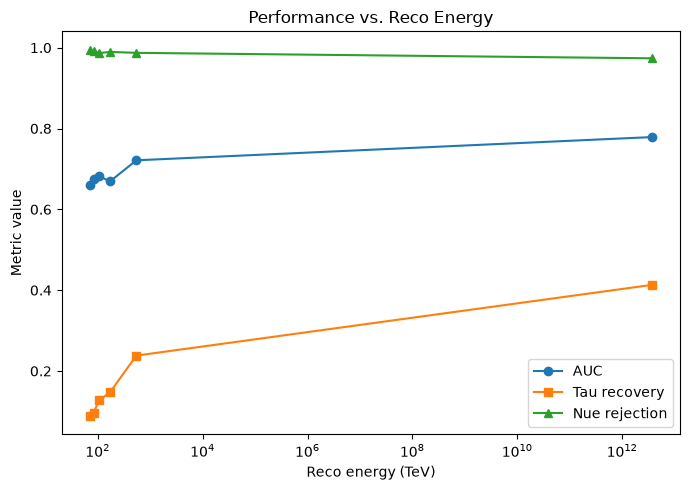

       bin range (TeV)   n_tau   n_nue  tau frac      AUC
[    65.0,    100.0)    3615    4354     0.454   0.6675
[   100.0,    200.0)    2430    2573     0.486   0.6768
[   200.0,    500.0)    1416    1308     0.520   0.7231
[   500.0,   1000.0)     685     525     0.566   0.7130
[  1000.0,   2500.0)     643     396     0.619   0.7399
[  2500.0,   6000.0)     441     280     0.612   0.7855
[  6000.0,      inf)     636     511     0.554   0.8157


In [7]:
df = pd.read_csv("trained_model/infer_GAT_0p3dropout_weightdecay5e4_64batchsize_focalloss2p/scores.csv")
threshold = 0.7
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")


thresholds = np.linspace(0.0, 1.0, 1001)
recoveries = np.array([tau_recovery(y_true, y_prob, t) for t in thresholds])
rejections = np.array([nue_rejection(y_true, y_prob, t) for t in thresholds])

combined = recoveries + rejections  # maximize this
best_idx = np.argmax(combined)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")
print(f"  Sum:           {combined[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.plot(thresholds, combined / 2, "--", color="gray", alpha=0.7, label="Mean(recovery, rejection)")
ax.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
           label=f"best threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()


alpha = 0.7  # weight on nue rejection; (1-alpha) on tau recovery. alpha=0.5 == unweighted.

weighted_score = alpha * rejections + (1 - alpha) * recoveries
best_idx = np.argmax(weighted_score)
best_threshold = thresholds[best_idx]

print(f"alpha={alpha}  ->  best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")

alphas = np.linspace(0.5, 1.0, 6)
print(f"{'alpha':>6} {'threshold':>10} {'recovery':>10} {'rejection':>10}")
for a in alphas:
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    print(f"{a:6.2f} {thresholds[idx]:10.4f} {recoveries[idx]:10.4f} {rejections[idx]:10.4f}")


fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery")
ax.plot(thresholds, rejections, label="Nue rejection")
for a, color in zip(alphas, plt.cm.viridis(np.linspace(0.2, 0.9, len(alphas)))):
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    ax.axvline(thresholds[idx], color=color, linestyle=":", alpha=0.8,
               label=f"alpha={a} -> t={thresholds[idx]:.2f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Threshold vs. Rejection-Weighted Objective")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()


energy = df["reco_energy_tev"].values

# --- 1. Score vs. energy scatter, colored by true class + misclassification ---
correct = y_pred == y_true

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for label, name, color in [(0, "nue", "tab:orange"), (1, "tau", "tab:blue")]:
    mask = y_true == label
    ax.scatter(energy[mask & correct], y_prob[mask & correct],
               s=14, color=color, alpha=0.6, label=f"{name} (correct)")
    ax.scatter(energy[mask & ~correct], y_prob[mask & ~correct],
               s=26, facecolors="none", edgecolors=color, linewidths=1.3,
               label=f"{name} (misclassified)")
ax.axhline(threshold, color="gray", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("P(tau)")
ax.set_title("Score vs. Reco Energy")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# --- 2. Energy-binned AUC / recovery / rejection ---
n_bins = 6
bin_edges = np.quantile(energy, np.linspace(0, 1, n_bins + 1))
bin_edges[0], bin_edges[-1] = bin_edges[0] - 1e-6, bin_edges[-1] + 1e-6

print(f"\n{'bin range (TeV)':>28} {'n_tau':>7} {'n_nue':>7} {'AUC':>8} "
      f"{'recovery':>10} {'rejection':>10}")
bin_results = []
for i in range(n_bins):
    mask = (energy >= bin_edges[i]) & (energy < bin_edges[i + 1])
    n_tau = int((y_true[mask] == 1).sum())
    n_nue = int((y_true[mask] == 0).sum())
    auc_bin = roc_auc_score(y_true[mask], y_prob[mask]) if len(np.unique(y_true[mask])) >= 2 else float("nan")
    rec_bin = tau_recovery(y_true[mask], y_prob[mask], threshold)
    rej_bin = nue_rejection(y_true[mask], y_prob[mask], threshold)
    bin_results.append({"lo": bin_edges[i], "hi": bin_edges[i+1], "auc": auc_bin,
                         "recovery": rec_bin, "rejection": rej_bin})
    print(f"[{bin_edges[i]:9.1f}, {bin_edges[i+1]:9.1f}) {n_tau:7d} {n_nue:7d} "
          f"{auc_bin:8.4f} {rec_bin:10.4f} {rej_bin:10.4f}")

bin_centers = [(r["lo"] + r["hi"]) / 2 for r in bin_results]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bin_centers, [r["auc"] for r in bin_results], "o-", label="AUC")
ax.plot(bin_centers, [r["recovery"] for r in bin_results], "s-", label="Tau recovery")
ax.plot(bin_centers, [r["rejection"] for r in bin_results], "^-", label="Nue rejection")
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("Metric value")
ax.set_title("Performance vs. Reco Energy")
ax.legend()
plt.tight_layout()
plt.show()

df_clean = df[df["reco_energy_tev"] < 1e5].copy()  # drop the corrupted event(s)
energy = df_clean["reco_energy_tev"].values
y_true_c = df_clean["true_label"].values
y_prob_c = df_clean["prob_tau"].values

fixed_edges = [65, 100, 200, 500, 1000, 2500, 6000, np.inf]
print(f"{'bin range (TeV)':>22} {'n_tau':>7} {'n_nue':>7} {'tau frac':>9} {'AUC':>8}")
for i in range(len(fixed_edges) - 1):
    mask = (energy >= fixed_edges[i]) & (energy < fixed_edges[i + 1])
    n_tau = int((y_true_c[mask] == 1).sum())
    n_nue = int((y_true_c[mask] == 0).sum())
    tau_frac = n_tau / max(n_tau + n_nue, 1)
    auc_bin = roc_auc_score(y_true_c[mask], y_prob_c[mask]) if len(np.unique(y_true_c[mask])) >= 2 else float("nan")
    print(f"[{fixed_edges[i]:8.1f}, {fixed_edges[i+1]:8.1f}) {n_tau:7d} {n_nue:7d} {tau_frac:9.3f} {auc_bin:8.4f}")

AUC:        0.8059
Accuracy:   0.6408
Precision:  0.8166
Recall:     0.3630
F1:         0.5026
Brier:      0.1874
Log loss:   0.7227
Confusion matrix [tn=1837, fp=163, fn=1274, tp=726]
  Specificity (TNR): 0.9185
  FPR:               0.0815


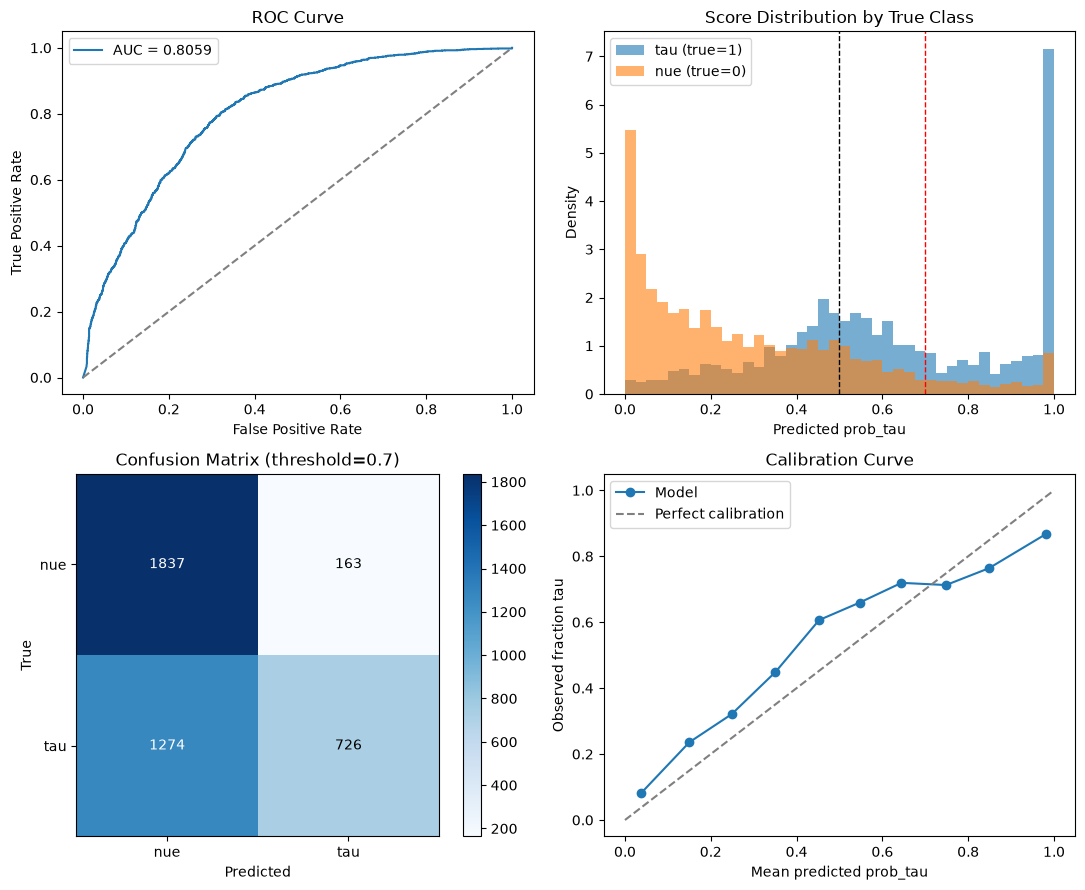

Best threshold: 0.3830
  Tau recovery:  0.8025
  Nue rejection: 0.6795
  Sum:           1.4820


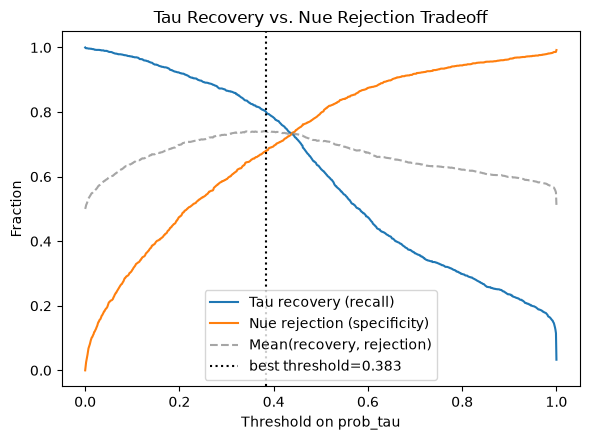

alpha=0.7  ->  best threshold: 0.5820
  Tau recovery:  0.4995
  Nue rejection: 0.8645
 alpha  threshold   recovery  rejection
  0.50     0.3830     0.8025     0.6795
  0.60     0.4470     0.7205     0.7440
  0.70     0.5820     0.4995     0.8645
  0.80     0.9120     0.2265     0.9685
  0.90     0.9950     0.1440     0.9860
  1.00     1.0000     0.0330     0.9920


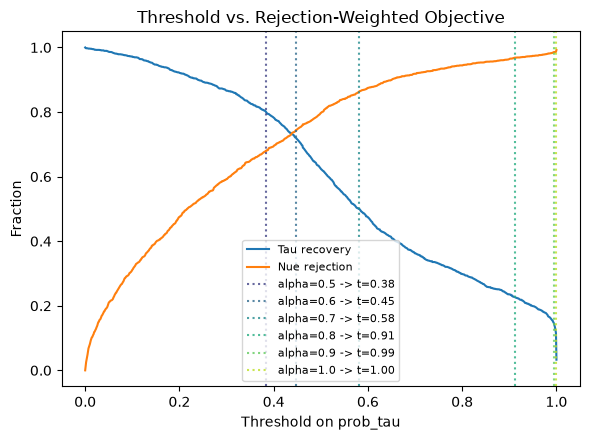

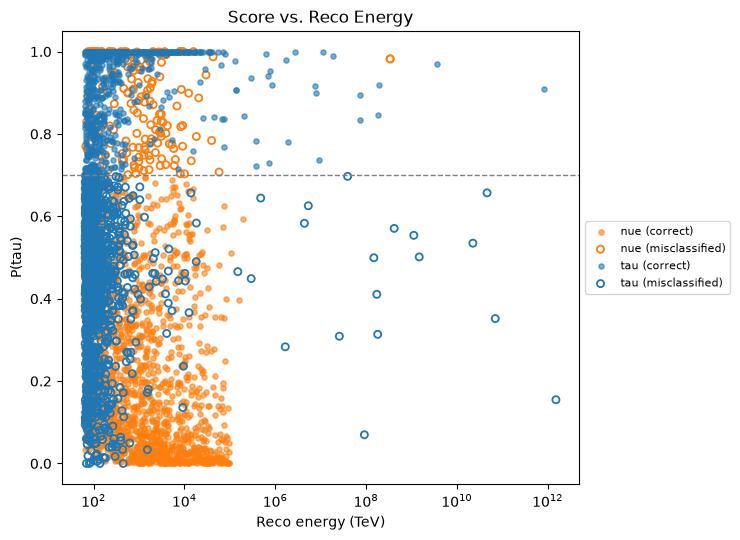


             bin range (TeV)   n_tau   n_nue      AUC   recovery  rejection
[     65.0,      79.3)     493     174   0.7413     0.2089     0.9598
[     79.3,     105.3)     472     194   0.7379     0.2754     0.9381
[    105.3,     177.9)     429     238   0.7482     0.3240     0.9454
[    177.9,     534.5)     344     322   0.8071     0.4826     0.9317
[    534.5,    3072.1)     132     535   0.9035     0.7045     0.8692
[   3072.1, 1521884300000.0)     129     537   0.9333     0.7364     0.9274


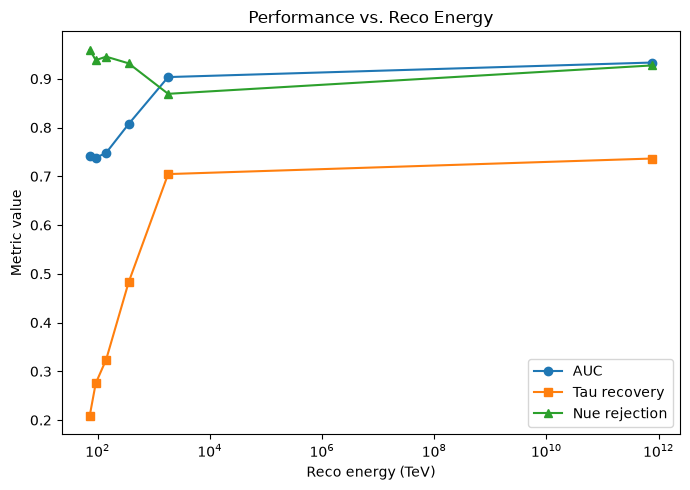

       bin range (TeV)   n_tau   n_nue  tau frac      AUC
[    65.0,    100.0)     897     341     0.725   0.7349
[   100.0,    200.0)     545     305     0.641   0.7487
[   200.0,    500.0)     287     257     0.528   0.8166
[   500.0,   1000.0)      72     213     0.253   0.8575
[  1000.0,   2500.0)      62     285     0.179   0.9338
[  2500.0,   6000.0)      38     208     0.154   0.9427
[  6000.0,      inf)      54     386     0.123   0.9572


In [ ]:
df = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/infer_GAT_0p3dropout_weightdecay5e4_64batchsize_a0p3valfrav_2k/scores.csv")
threshold = 0.7
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")


thresholds = np.linspace(0.0, 1.0, 1001)
recoveries = np.array([tau_recovery(y_true, y_prob, t) for t in thresholds])
rejections = np.array([nue_rejection(y_true, y_prob, t) for t in thresholds])

combined = recoveries + rejections  # maximize this
best_idx = np.argmax(combined)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")
print(f"  Sum:           {combined[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.plot(thresholds, combined / 2, "--", color="gray", alpha=0.7, label="Mean(recovery, rejection)")
ax.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
           label=f"best threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()


alpha = 0.7  # weight on nue rejection; (1-alpha) on tau recovery. alpha=0.5 == unweighted.

weighted_score = alpha * rejections + (1 - alpha) * recoveries
best_idx = np.argmax(weighted_score)
best_threshold = thresholds[best_idx]

print(f"alpha={alpha}  ->  best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")

alphas = np.linspace(0.5, 1.0, 6)
print(f"{'alpha':>6} {'threshold':>10} {'recovery':>10} {'rejection':>10}")
for a in alphas:
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    print(f"{a:6.2f} {thresholds[idx]:10.4f} {recoveries[idx]:10.4f} {rejections[idx]:10.4f}")


fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery")
ax.plot(thresholds, rejections, label="Nue rejection")
for a, color in zip(alphas, plt.cm.viridis(np.linspace(0.2, 0.9, len(alphas)))):
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    ax.axvline(thresholds[idx], color=color, linestyle=":", alpha=0.8,
               label=f"alpha={a} -> t={thresholds[idx]:.2f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Threshold vs. Rejection-Weighted Objective")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()


energy = df["reco_energy_tev"].values

# --- 1. Score vs. energy scatter, colored by true class + misclassification ---
correct = y_pred == y_true

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for label, name, color in [(0, "nue", "tab:orange"), (1, "tau", "tab:blue")]:
    mask = y_true == label
    ax.scatter(energy[mask & correct], y_prob[mask & correct],
               s=14, color=color, alpha=0.6, label=f"{name} (correct)")
    ax.scatter(energy[mask & ~correct], y_prob[mask & ~correct],
               s=26, facecolors="none", edgecolors=color, linewidths=1.3,
               label=f"{name} (misclassified)")
ax.axhline(threshold, color="gray", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("P(tau)")
ax.set_title("Score vs. Reco Energy")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# --- 2. Energy-binned AUC / recovery / rejection ---
n_bins = 6
bin_edges = np.quantile(energy, np.linspace(0, 1, n_bins + 1))
bin_edges[0], bin_edges[-1] = bin_edges[0] - 1e-6, bin_edges[-1] + 1e-6

print(f"\n{'bin range (TeV)':>28} {'n_tau':>7} {'n_nue':>7} {'AUC':>8} "
      f"{'recovery':>10} {'rejection':>10}")
bin_results = []
for i in range(n_bins):
    mask = (energy >= bin_edges[i]) & (energy < bin_edges[i + 1])
    n_tau = int((y_true[mask] == 1).sum())
    n_nue = int((y_true[mask] == 0).sum())
    auc_bin = roc_auc_score(y_true[mask], y_prob[mask]) if len(np.unique(y_true[mask])) >= 2 else float("nan")
    rec_bin = tau_recovery(y_true[mask], y_prob[mask], threshold)
    rej_bin = nue_rejection(y_true[mask], y_prob[mask], threshold)
    bin_results.append({"lo": bin_edges[i], "hi": bin_edges[i+1], "auc": auc_bin,
                         "recovery": rec_bin, "rejection": rej_bin})
    print(f"[{bin_edges[i]:9.1f}, {bin_edges[i+1]:9.1f}) {n_tau:7d} {n_nue:7d} "
          f"{auc_bin:8.4f} {rec_bin:10.4f} {rej_bin:10.4f}")

bin_centers = [(r["lo"] + r["hi"]) / 2 for r in bin_results]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bin_centers, [r["auc"] for r in bin_results], "o-", label="AUC")
ax.plot(bin_centers, [r["recovery"] for r in bin_results], "s-", label="Tau recovery")
ax.plot(bin_centers, [r["rejection"] for r in bin_results], "^-", label="Nue rejection")
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("Metric value")
ax.set_title("Performance vs. Reco Energy")
ax.legend()
plt.tight_layout()
plt.show()

df_clean = df[df["reco_energy_tev"] < 1e5].copy()  # drop the corrupted event(s)
energy = df_clean["reco_energy_tev"].values
y_true_c = df_clean["true_label"].values
y_prob_c = df_clean["prob_tau"].values

fixed_edges = [65, 100, 200, 500, 1000, 2500, 6000, np.inf]
print(f"{'bin range (TeV)':>22} {'n_tau':>7} {'n_nue':>7} {'tau frac':>9} {'AUC':>8}")
for i in range(len(fixed_edges) - 1):
    mask = (energy >= fixed_edges[i]) & (energy < fixed_edges[i + 1])
    n_tau = int((y_true_c[mask] == 1).sum())
    n_nue = int((y_true_c[mask] == 0).sum())
    tau_frac = n_tau / max(n_tau + n_nue, 1)
    auc_bin = roc_auc_score(y_true_c[mask], y_prob_c[mask]) if len(np.unique(y_true_c[mask])) >= 2 else float("nan")
    print(f"[{fixed_edges[i]:8.1f}, {fixed_edges[i+1]:8.1f}) {n_tau:7d} {n_nue:7d} {tau_frac:9.3f} {auc_bin:8.4f}")

AUC:        0.7204
Accuracy:   0.6679
Precision:  0.7668
Recall:     0.4826
F1:         0.5924
Brier:      0.2093
Log loss:   0.6191
Confusion matrix [tn=6420, fp=1104, fn=3893, tp=3631]
  Specificity (TNR): 0.8533
  FPR:               0.1467


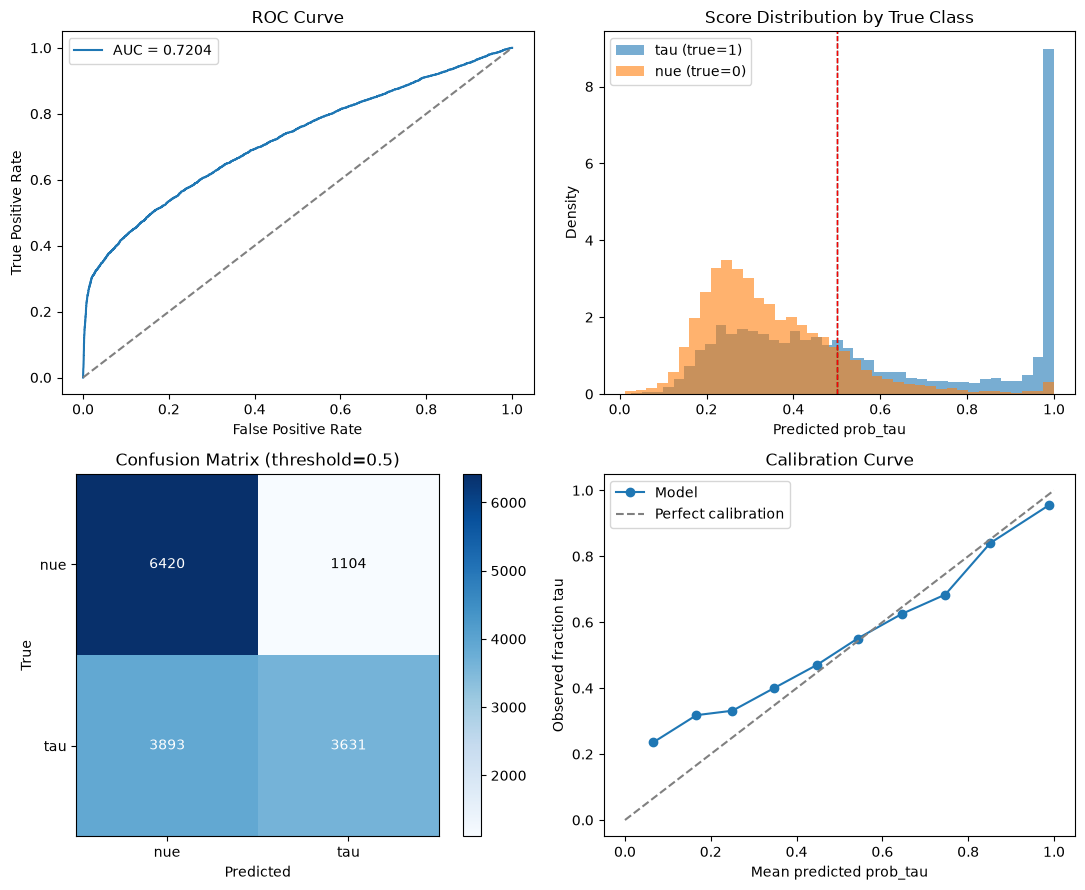

Best threshold: 0.4840
  Tau recovery:  0.5049
  Nue rejection: 0.8343
  Sum:           1.3392


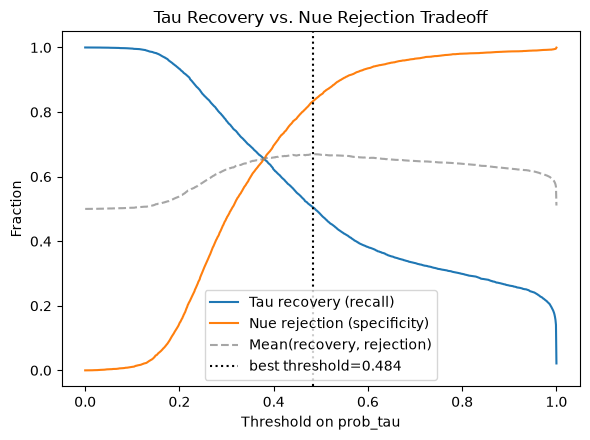

alpha=0.7  ->  best threshold: 0.7790
  Tau recovery:  0.3054
  Nue rejection: 0.9790
 alpha  threshold   recovery  rejection
  0.50     0.4840     0.5049     0.8343
  0.60     0.6120     0.3756     0.9413
  0.70     0.7790     0.3054     0.9790
  0.80     0.7940     0.3009     0.9805
  0.90     0.9400     0.2487     0.9899
  1.00     1.0000     0.0214     0.9996


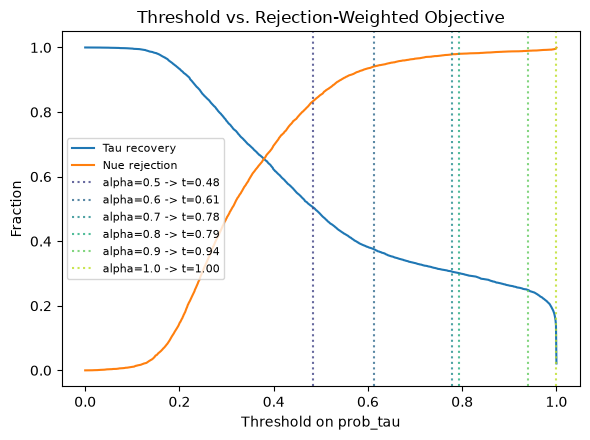

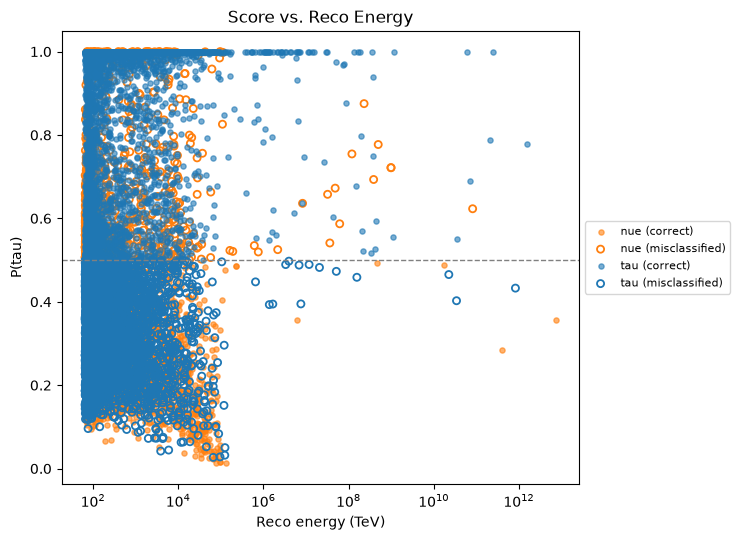


             bin range (TeV)   n_tau   n_nue      AUC   recovery  rejection
[     65.0,      76.5)    1053    1455   0.6897     0.4169     0.8357
[     76.5,      95.0)    1058    1450   0.6847     0.4178     0.8559
[     95.0,     134.5)    1143    1365   0.7205     0.4689     0.8740
[    134.5,     282.4)    1238    1270   0.6911     0.4354     0.8740
[    282.4,    1341.0)    1449    1059   0.7150     0.4707     0.8754
[   1341.0, 7397392000000.0)    1583     924   0.7916     0.6273     0.7922


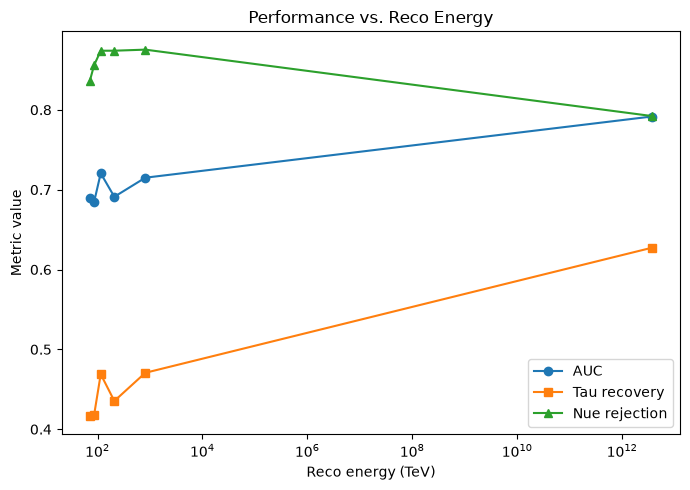

       bin range (TeV)   n_tau   n_nue  tau frac      AUC
[    65.0,    100.0)    2319    3189     0.421   0.6891
[   100.0,    200.0)    1695    1913     0.470   0.7136
[   200.0,    500.0)    1117     952     0.540   0.7011
[   500.0,   1000.0)     584     418     0.583   0.7040
[  1000.0,   2500.0)     614     336     0.646   0.7390
[  2500.0,   6000.0)     467     254     0.648   0.7730
[  6000.0,      inf)     610     433     0.585   0.8199


In [6]:
df = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/trained_model/infer_NewRun_GAT_0p3dropout_weightdecay5e4_64batchsize_0p3valfrac/scores.csv")
threshold = 0.5
y_true = df["true_label"].values
y_prob = df["prob_tau"].values
y_pred = (y_prob >= threshold).astype(int)

auc     = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
brier   = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"AUC:        {auc:.4f}")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1:         {f1:.4f}")
print(f"Brier:      {brier:.4f}")
print(f"Log loss:   {logloss:.4f}")
print(f"Confusion matrix [tn={tn}, fp={fp}, fn={fn}, tp={tp}]")
print(f"  Specificity (TNR): {tn/(tn+fp):.4f}")
print(f"  FPR:               {fp/(tn+fp):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# 1. ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_xlabel("False Positive Rate")
axes[0, 0].set_ylabel("True Positive Rate")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()

# 2. Score distribution by true class
axes[0, 1].hist(y_prob[y_true == 1], bins=40, alpha=0.6, label="tau (true=1)", density=True)
axes[0, 1].hist(y_prob[y_true == 0], bins=40, alpha=0.6, label="nue (true=0)", density=True)
axes[0, 1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0, 1].axvline(threshold, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_xlabel("Predicted prob_tau")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Score Distribution by True Class")
axes[0, 1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["nue", "tau"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["nue", "tau"])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("True")
axes[1, 0].set_title(f"Confusion Matrix (threshold={threshold})")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[1, 0])

# 4. Calibration curve (reliability diagram)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted prob_tau")
axes[1, 1].set_ylabel("Observed fraction tau")
axes[1, 1].set_title("Calibration Curve")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


def tau_recovery(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tau_mask = (y_true == 1)
    recovered = (y_pred[tau_mask] == 1).sum()
    total_tau = tau_mask.sum()
    return recovered / total_tau if total_tau > 0 else float("nan")

def nue_rejection(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    nue_mask = (y_true == 0)
    rejected = (y_pred[nue_mask] == 0).sum()
    total_nue = nue_mask.sum()
    return rejected / total_nue if total_nue > 0 else float("nan")


thresholds = np.linspace(0.0, 1.0, 1001)
recoveries = np.array([tau_recovery(y_true, y_prob, t) for t in thresholds])
rejections = np.array([nue_rejection(y_true, y_prob, t) for t in thresholds])

combined = recoveries + rejections  # maximize this
best_idx = np.argmax(combined)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")
print(f"  Sum:           {combined[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery (recall)")
ax.plot(thresholds, rejections, label="Nue rejection (specificity)")
ax.plot(thresholds, combined / 2, "--", color="gray", alpha=0.7, label="Mean(recovery, rejection)")
ax.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5,
           label=f"best threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Tau Recovery vs. Nue Rejection Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()


alpha = 0.7  # weight on nue rejection; (1-alpha) on tau recovery. alpha=0.5 == unweighted.

weighted_score = alpha * rejections + (1 - alpha) * recoveries
best_idx = np.argmax(weighted_score)
best_threshold = thresholds[best_idx]

print(f"alpha={alpha}  ->  best threshold: {best_threshold:.4f}")
print(f"  Tau recovery:  {recoveries[best_idx]:.4f}")
print(f"  Nue rejection: {rejections[best_idx]:.4f}")

alphas = np.linspace(0.5, 1.0, 6)
print(f"{'alpha':>6} {'threshold':>10} {'recovery':>10} {'rejection':>10}")
for a in alphas:
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    print(f"{a:6.2f} {thresholds[idx]:10.4f} {recoveries[idx]:10.4f} {rejections[idx]:10.4f}")


fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, recoveries, label="Tau recovery")
ax.plot(thresholds, rejections, label="Nue rejection")
for a, color in zip(alphas, plt.cm.viridis(np.linspace(0.2, 0.9, len(alphas)))):
    ws = a * rejections + (1 - a) * recoveries
    idx = np.argmax(ws)
    ax.axvline(thresholds[idx], color=color, linestyle=":", alpha=0.8,
               label=f"alpha={a} -> t={thresholds[idx]:.2f}")
ax.set_xlabel("Threshold on prob_tau")
ax.set_ylabel("Fraction")
ax.set_title("Threshold vs. Rejection-Weighted Objective")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()


energy = df["reco_energy_tev"].values

# --- 1. Score vs. energy scatter, colored by true class + misclassification ---
correct = y_pred == y_true

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for label, name, color in [(0, "nue", "tab:orange"), (1, "tau", "tab:blue")]:
    mask = y_true == label
    ax.scatter(energy[mask & correct], y_prob[mask & correct],
               s=14, color=color, alpha=0.6, label=f"{name} (correct)")
    ax.scatter(energy[mask & ~correct], y_prob[mask & ~correct],
               s=26, facecolors="none", edgecolors=color, linewidths=1.3,
               label=f"{name} (misclassified)")
ax.axhline(threshold, color="gray", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("P(tau)")
ax.set_title("Score vs. Reco Energy")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# --- 2. Energy-binned AUC / recovery / rejection ---
n_bins = 6
bin_edges = np.quantile(energy, np.linspace(0, 1, n_bins + 1))
bin_edges[0], bin_edges[-1] = bin_edges[0] - 1e-6, bin_edges[-1] + 1e-6

print(f"\n{'bin range (TeV)':>28} {'n_tau':>7} {'n_nue':>7} {'AUC':>8} "
      f"{'recovery':>10} {'rejection':>10}")
bin_results = []
for i in range(n_bins):
    mask = (energy >= bin_edges[i]) & (energy < bin_edges[i + 1])
    n_tau = int((y_true[mask] == 1).sum())
    n_nue = int((y_true[mask] == 0).sum())
    auc_bin = roc_auc_score(y_true[mask], y_prob[mask]) if len(np.unique(y_true[mask])) >= 2 else float("nan")
    rec_bin = tau_recovery(y_true[mask], y_prob[mask], threshold)
    rej_bin = nue_rejection(y_true[mask], y_prob[mask], threshold)
    bin_results.append({"lo": bin_edges[i], "hi": bin_edges[i+1], "auc": auc_bin,
                         "recovery": rec_bin, "rejection": rej_bin})
    print(f"[{bin_edges[i]:9.1f}, {bin_edges[i+1]:9.1f}) {n_tau:7d} {n_nue:7d} "
          f"{auc_bin:8.4f} {rec_bin:10.4f} {rej_bin:10.4f}")

bin_centers = [(r["lo"] + r["hi"]) / 2 for r in bin_results]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bin_centers, [r["auc"] for r in bin_results], "o-", label="AUC")
ax.plot(bin_centers, [r["recovery"] for r in bin_results], "s-", label="Tau recovery")
ax.plot(bin_centers, [r["rejection"] for r in bin_results], "^-", label="Nue rejection")
ax.set_xscale("log")
ax.set_xlabel("Reco energy (TeV)")
ax.set_ylabel("Metric value")
ax.set_title("Performance vs. Reco Energy")
ax.legend()
plt.tight_layout()
plt.show()

df_clean = df[df["reco_energy_tev"] < 1e5].copy()  # drop the corrupted event(s)
energy = df_clean["reco_energy_tev"].values
y_true_c = df_clean["true_label"].values
y_prob_c = df_clean["prob_tau"].values

fixed_edges = [65, 100, 200, 500, 1000, 2500, 6000, np.inf]
print(f"{'bin range (TeV)':>22} {'n_tau':>7} {'n_nue':>7} {'tau frac':>9} {'AUC':>8}")
for i in range(len(fixed_edges) - 1):
    mask = (energy >= fixed_edges[i]) & (energy < fixed_edges[i + 1])
    n_tau = int((y_true_c[mask] == 1).sum())
    n_nue = int((y_true_c[mask] == 0).sum())
    tau_frac = n_tau / max(n_tau + n_nue, 1)
    auc_bin = roc_auc_score(y_true_c[mask], y_prob_c[mask]) if len(np.unique(y_true_c[mask])) >= 2 else float("nan")
    print(f"[{fixed_edges[i]:8.1f}, {fixed_edges[i+1]:8.1f}) {n_tau:7d} {n_nue:7d} {tau_frac:9.3f} {auc_bin:8.4f}")